# Exploratory Data Analysis


**1. Strucural Examination**

- 1.1 Shape

- 1.2 Unique ID's

- 1.3 Win Outcome Balance

**2 Pitching Analysis**

- 2.1 Starting Pitcher Distribution

- 2.2 Distribution by Win

- 2.3 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
game_level_features = pd.read_parquet("data/aggregated/game_level_features_22_25.parquet")
game_level_features["game_date"] = pd.to_datetime(game_level_features["game_date"], errors="coerce")
game_level_features.head(10)

,game_id,game_date,home_team,away_team,starter_pitcher_name_home,starter_pitcher_name_away,Δstarter_FIP_3G,Δstarter_WHIP_3G,Δstarter_K9_3G,Δstarter_HR9_3G,...,Δroll_3G_ISO,Δroll_7G_OBP,Δroll_7G_ISO,ΔBIP_out_rate_3G,ΔBIP_out_rate_7G,home_win,run_diff,Δwin_pct_7G,Δwin_pct_10G,ballpark
0,661042,2022-04-07,LAA,HOU,"Ohtani, Shohei","Valdez, Framber",-0.501346,-0.173269,2.362500,0.228462,...,-0.013193,-0.027160,-0.013193,-0.030054,-0.030054,0,-2,-0.111111,-0.111111,LAA
1,661577,2022-04-07,ATL,CIN,"Fried, Max","Mahle, Tyler",-0.500258,-0.156226,-1.896095,-0.385842,...,0.006274,-0.011229,0.006274,0.016629,0.016629,0,-3,0.034238,0.034238,ATL
2,662021,2022-04-07,STL,PIT,"Wainwright, Adam","Brubaker, JT",-1.496179,-0.272351,-1.838997,-1.136493,...,0.038504,0.004731,0.038504,0.028652,0.028652,1,9,0.179012,0.179012,STL
3,662571,2022-04-07,WSH,NYM,"Corbin, Patrick","Megill, Tylor",0.740873,0.193245,-2.388419,0.048493,...,0.008000,0.021413,0.008000,-0.004304,-0.004304,0,-4,-0.074074,-0.074074,WSH
4,662766,2022-04-07,KC,CLE,"Greinke, Zack","Bieber, Shane",1.678132,-0.063212,-6.238713,0.528978,...,-0.019450,0.005893,-0.019450,-0.019316,-0.019316,1,2,-0.037037,-0.037037,KC
5,663178,2022-04-07,CHC,MIL,"Hendricks, Kyle","Burnes, Corbin",3.291359,0.458473,-6.062442,1.182810,...,0.007685,-0.005448,0.007685,-0.019441,-0.019441,1,1,-0.148148,-0.148148,CHC
6,663418,2022-04-07,AZ,SD,"Bumgarner, Madison","Darvish, Yu",0.751171,0.133199,-3.039157,-0.018072,...,-0.012834,-0.011187,-0.012834,-0.013363,-0.013363,1,2,-0.166667,-0.166667,AZ
7,661041,2022-04-08,LAA,HOU,"Detmers, Reid","Odorizzi, Jake",1.796577,0.580195,0.382809,0.753655,...,-0.216749,-0.095925,-0.216749,-0.079051,-0.079051,0,-7,-1.000000,-1.000000,LAA
8,661131,2022-04-08,PHI,ATH,"Nola, Aaron","Montas, Frankie",-0.005405,-0.049099,1.079730,0.327027,...,-0.001215,-0.000515,-0.001215,-0.004885,-0.004885,1,4,-0.024691,-0.024691,PHI
9,661333,2022-04-08,NYY,BOS,"Cole, Gerrit","Eovaldi, Nathan",0.132353,-0.165441,2.382353,0.446691,...,-0.016365,-0.005154,-0.016365,0.034455,0.034455,1,1,0.000000,0.000000,NYY


## 1 Structural Examination

### 1.1 Shape

In [3]:
game_level_features.shape

(9719, 33)

### 1.2 Unique ID's

In [4]:
game_level_features["game_id"].is_unique

True

### 1.3 Win Outcome Balance

In [5]:
game_level_features["home_win"].value_counts(normalize=True)

home_win
1    0.529581
0    0.470419
Name: proportion, dtype: float64

## 2. Starting Pitching Analysis 

### 2.1 Starting Pitcher Distribution

In [6]:
game_level_features.filter(like="Δstarter").describe()

,Δstarter_FIP_3G,Δstarter_WHIP_3G,Δstarter_K9_3G,Δstarter_HR9_3G,Δstarter_FIP_7G,Δstarter_WHIP_7G,Δstarter_K9_7G,Δstarter_HR9_7G
count,9719.000000,9.719000e+03,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000
mean,0.017502,9.257598e-03,-0.013511,-0.003982,0.025266,0.008290,-0.017261,0.003231
std,2.792398,7.483961e-01,3.709555,1.585772,2.418433,0.663575,3.233184,1.354392
min,-62.750000,-2.294118e+01,-21.288462,-26.470588,-62.750000,-22.941176,-20.647059,-26.470588
25%,-1.472975,-3.573455e-01,-2.376179,-0.857143,-1.163762,-0.278768,-1.985711,-0.642367
50%,0.000000,2.220446e-16,0.000000,0.000000,0.015345,0.006435,0.000000,0.000000
75%,1.507484,3.750981e-01,2.376567,0.854376,1.218488,0.297676,1.981252,0.652020
max,35.666667,1.076786e+01,20.543478,21.000000,35.666667,10.956522,20.008929,21.000000


In [7]:
'''
Move to Script!
'''

def plot_delta_boxplots(
    df,
    like: str,
    title: str | None = None,
    feature_col: str = "Feature",
    value_col: str = "Value",
    figsize: tuple[int, int] = (12, 5),
    rotate_xticks: int = 90,
    dropna: bool = True,
) -> None:
    """
    Boxplot distributions for a set of columns selected via df.filter(like=...).

    Intended for quick EDA of delta features (e.g., Δstarter, Δbullpen).
    """
    sub = df.filter(like=like)
    if sub.shape[1] == 0:
        raise ValueError(f"No columns matched like='{like}'")

    long = sub.melt(var_name=feature_col, value_name=value_col)
    if dropna:
        long = long.dropna()

    plt.figure(figsize=figsize)
    sns.boxplot(data=long, x=feature_col, y=value_col)
    plt.xticks(rotation=rotate_xticks)
    plt.title(title or f"Boxplot Distribution for columns like '{like}'")
    plt.tight_layout()
    plt.show()

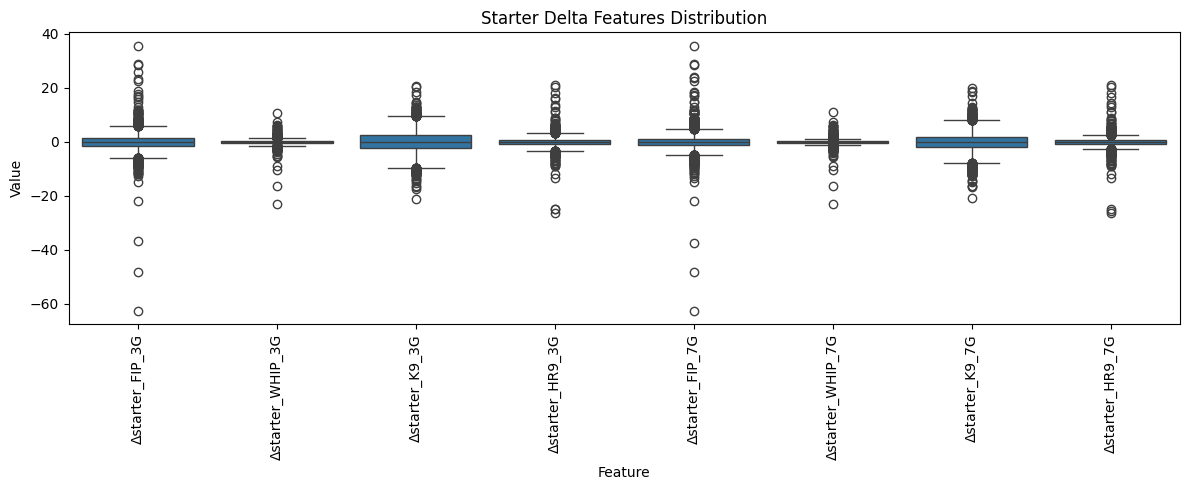

In [8]:
plot_delta_boxplots(game_level_features, like="Δstarter", title="Starter Delta Features Distribution")

#### Analysis

The distributions of the pitching delta features are generally centered around zero, with both the means and medians very close to zero. This is expected since the variables represent the difference between the home and away teams' metrics for a given game.

Overall, the distributions appear roughly symmetric around zero. Both the means and medians of the pitching delta features are very close to zero across all metrics, and the first and third quartiles are also fairly balanced around zero. This suggests that positive and negative pitching differences occur at similar rates across games.

As expected, the 3-game rolling windows (3G) show a wider spread compared to the 7-game rolling windows (7G). This makes sense because shorter rolling windows are more sensitive to recent performance and therefore tend to be noisier, while longer windows smooth out variability over a larger sample of games.

The number and magnitude of outliers appear relatively similar between the 3G and 7G windows, indicating that extreme differences between teams can occur regardless of the smoothing window.

Among the metrics, starter FIP exhibits the most extreme outliers, with some values reaching roughly −60 to +35. This likely reflects situations where there is a large difference in the recent performance of the two starting pitchers.

### 2.2 Distribution by Win

In [9]:
def plot_delta_boxplots_by_outcome(
    df: pd.DataFrame,
    like: str,
    outcome_col: str = "home_win",
    showmeans: bool = True,
    figsize: tuple[int, int] = (6, 4),
    title_suffix: str = "by Outcome"
) -> None:
    """
    Plot boxplots of delta features against a binary outcome column.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the outcome column and delta feature columns.
    like : str
        Substring used to filter columns, e.g. "Δstarter_" or "Δbullpen_".
    outcome_col : str
        Column used on the x-axis.
    showmeans : bool
        Whether to display the mean marker on each boxplot.
    figsize : tuple[int, int]
        Figure size for each plot.
    title_suffix : str
        Suffix to append to each plot title.

    Returns
    -------
    None
        Displays plots only.
    """
    delta_cols = df.filter(like=like).columns

    if len(delta_cols) == 0:
        raise ValueError(f"No columns found containing '{like}'.")

    for col in delta_cols:
        plt.figure(figsize=figsize)

        boxplot_kwargs = {
            "data": df,
            "x": outcome_col,
            "y": col,
        }

        if showmeans:
            boxplot_kwargs["showmeans"] = True
            boxplot_kwargs["meanprops"] = {
                "marker": "o",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 6
            }

        sns.boxplot(**boxplot_kwargs)
        plt.title(f"{col} {title_suffix}")
        plt.tight_layout()
        plt.show()

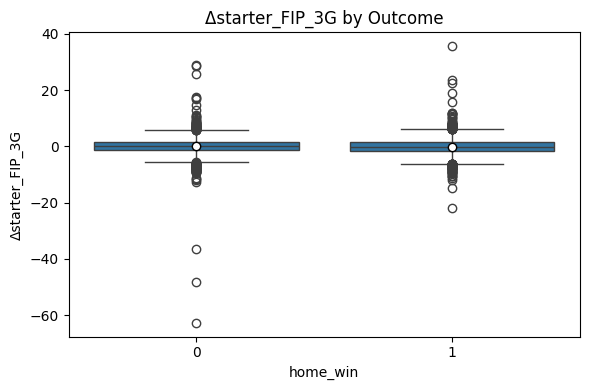

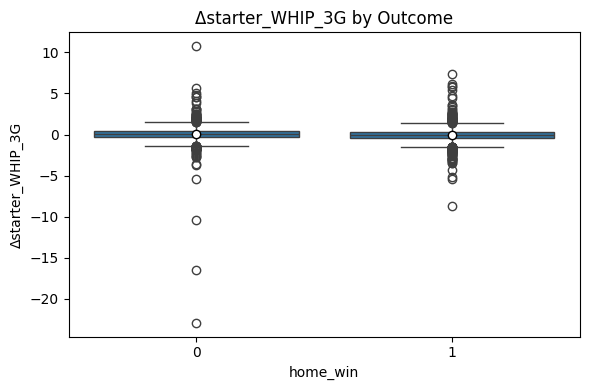

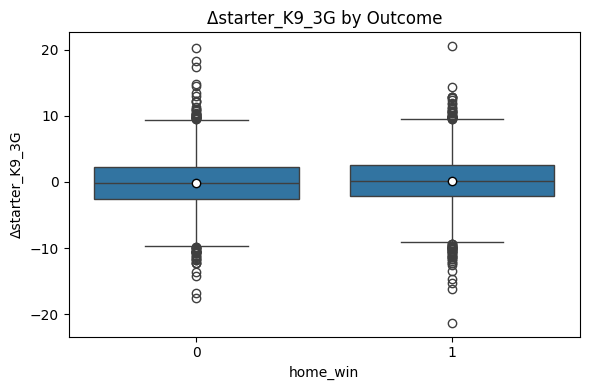

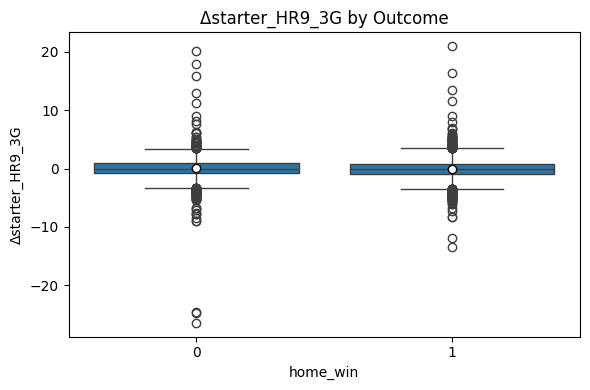

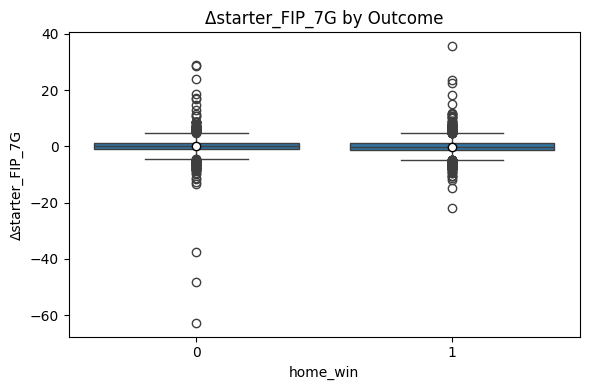

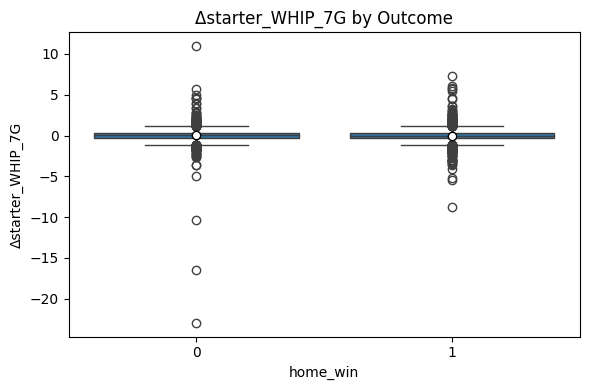

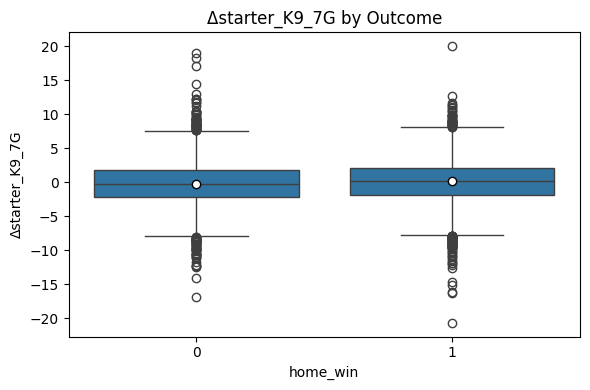

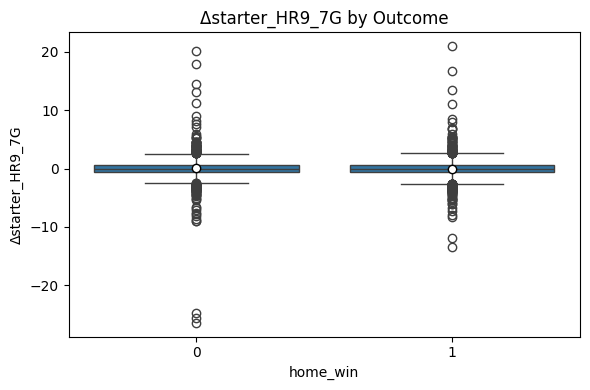

In [10]:
plot_delta_boxplots_by_outcome(
    game_level_features,
    like="Δstarter_",
    showmeans=True
)

#### Analysis

Across all starter delta features (FIP, WHIP, K9, and HR9) for both the 3-game and 7-game rolling windows, the distributions are centered very close to zero for both home wins and losses. Both the **median and mean values lie near zero**, indicating that in many games the recent performance of the home and away starting pitchers is relatively similar. The mean markers shown in the boxplots also appear close to the medians for most features, suggesting that the distributions are reasonably symmetric despite the presence of several extreme observations.

The interquartile ranges and overall spreads of the distributions are also largely overlapping between outcomes, suggesting that no single starter metric alone strongly separates wins from losses. However, slight directional tendencies are visible: negative values of metrics where lower is better (such as $\Delta FIP$ and $\Delta WHIP$) and positive values where higher is better (such as $\Delta K9$) appear somewhat more common in the home win group. In these cases, both the **means and medians shift slightly in the expected direction**, reinforcing the idea that when the home team's starting pitcher has performed better relative to the opposing starter in recent games, the likelihood of a home win increases modestly.

Overall, this suggests that starter matchup differences may contribute modest predictive signal, but are unlikely to fully explain game outcomes without considering other components such as bullpen performance and offensive strength.

###  2.3 Starting Pitcher Density Plots by Outcome

The density plots for the starting pitcher delta features illustrate the distribution of the recent pitching advantage between the home and away starting pitchers, conditional on game outcomes. Because these variables represent the difference between the home and away teams' recent performance, values near zero indicate evenly matched starting pitchers, while positive or negative values indicate an advantage for one team.


In [16]:
def plot_delta_density_by_outcome(
    df: pd.DataFrame,
    like: str,
    outcome_col: str = "home_win",
    figsize: tuple[int, int] = (6, 4),
    fill: bool = True,
    common_norm: bool = False,
    alpha: float = 0.4,
    add_zero_line: bool = True,
    title_prefix: str = "Density Plot:"
) -> None:
    """
    Plot KDE density curves of delta features by outcome.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the outcome column and delta feature columns.
    like : str
        Substring used to filter columns, e.g. "Δstarter_" or "Δbullpen_".
    outcome_col : str
        Column used for hue grouping.
    figsize : tuple[int, int]
        Figure size for each plot.
    fill : bool
        Whether to fill the KDE curves.
    common_norm : bool
        Whether to normalize across hue groups jointly.
    alpha : float
        Transparency for filled KDE curves.
    add_zero_line : bool
        Whether to add a vertical reference line at 0.
    title_prefix : str
        Prefix used in the plot title.

    Returns
    -------
    None
        Displays plots only.
    """
    delta_cols = df.filter(like=like).columns

    if len(delta_cols) == 0:
        raise ValueError(f"No columns found containing '{like}'.")

    for col in delta_cols:
        plt.figure(figsize=figsize)

        sns.kdeplot(
            data=df,
            x=col,
            hue=outcome_col,
            fill=fill,
            common_norm=common_norm,
            alpha=alpha
        )

        if add_zero_line:
            plt.axvline(0, linestyle="--", color="black", alpha=0.7)

        plt.title(f"{title_prefix} {col} by Outcome")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.tight_layout()
        plt.show()

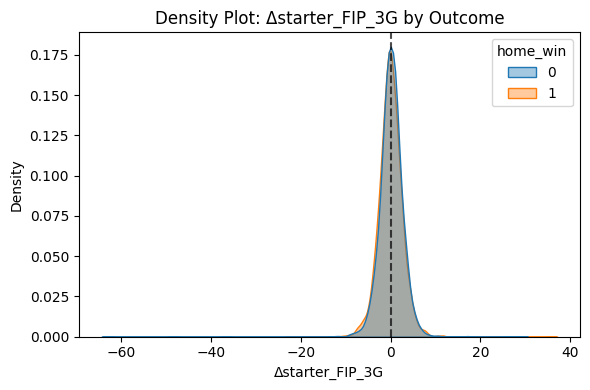

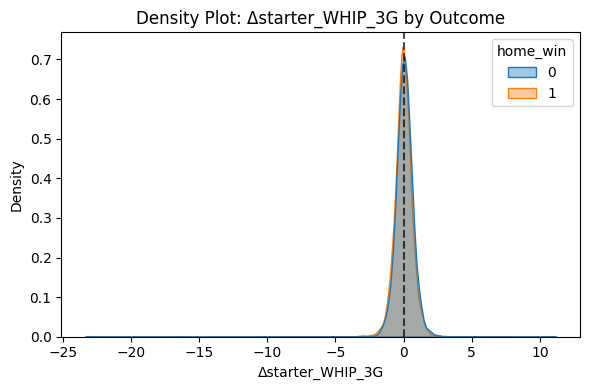

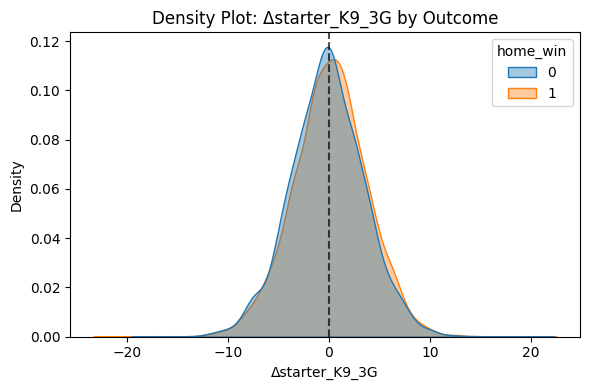

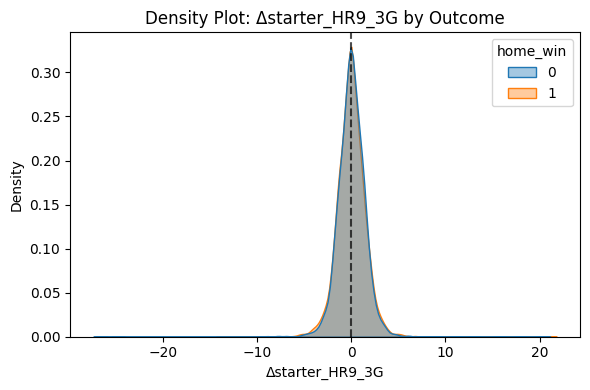

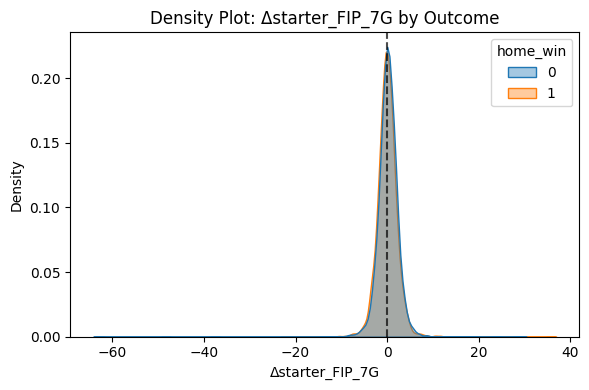

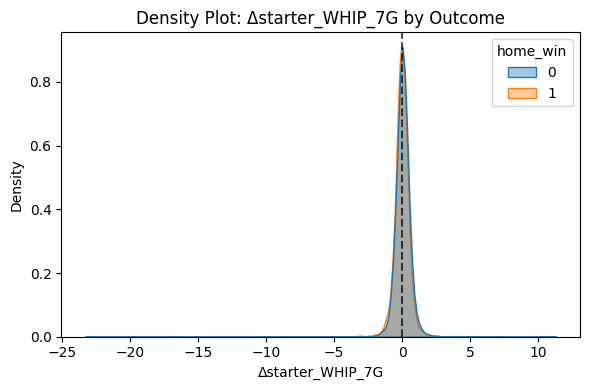

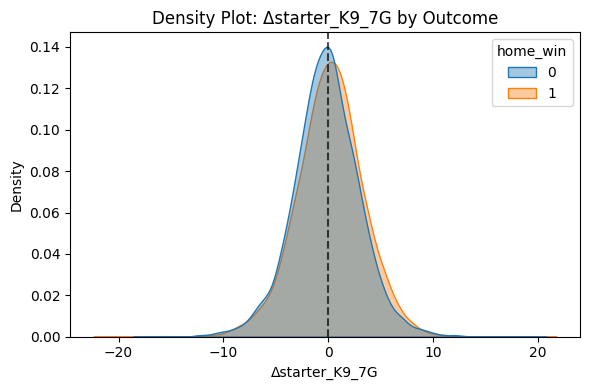

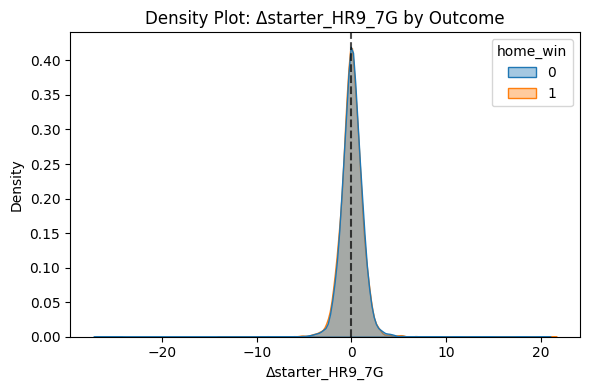

In [17]:
plot_delta_density_by_outcome(
    game_level_features,
    like="Δstarter_"
)

#### Analysis

Across all starting pitcher metrics (FIP, WHIP, K9, and HR9) and both rolling windows (3-game and 7-game), the distributions for home wins and losses are **highly concentrated around zero** and **overlap substantially**. This indicates that, in many games, the recent performance of the two starting pitchers entering the matchup is relatively similar. The vertical dashed line at zero highlights this point, as both outcome distributions peak very close to this value.

Despite the large degree of overlap, **small directional shifts can still be observed**. For metrics where lower values represent stronger pitching performance (such as $\Delta$FIP, $\Delta$WHIP, and $\Delta$HR9), the distribution associated with home wins tends to shift slightly toward **more negative values**, suggesting that home teams are somewhat more likely to win when their starting pitcher has recently performed better than the opposing starter. Conversely, for $\Delta$K9, where higher values indicate stronger performance, the distribution for home wins shifts slightly toward **more positive values**, indicating that higher recent strikeout rates for the home starter may contribute modestly to improved outcomes.

These results **reinforce the patterns observed in the earlier box plots**. The box plots showed that the means, medians, and interquartile ranges for wins and losses were very similar, while the density plots confirm that the overall shapes of the distributions are also highly overlapping. However, the density plots make the **subtle directional shifts between the win and loss distributions easier to visualize**, highlighting that small pitching advantages do appear slightly more frequently in games the home team wins.

Comparing the rolling windows, the **3-game distributions appear slightly wider and more variable** than the 7-game distributions, reflecting the greater volatility associated with shorter rolling windows. The 7-game metrics produce somewhat smoother and more concentrated distributions, as they average performance over a larger sample of recent games.

Overall, these plots suggest that while **relative starting pitcher performance contains some predictive information**, the signal is relatively weak on its own. The strong overlap between win and loss distributions indicates that starting pitcher differences alone are unlikely to determine game outcomes, and that game results are influenced by a broader set of factors including bullpen performance, offensive production, and other contextual variables.

## 3. Bullpen Pitching Analysis

### 3.1 Pitcher Distribution

In [10]:
game_level_features.filter(like="Δbullpen").describe()

,Δbullpen_FIP_3G,Δbullpen_WHIP_3G,Δbullpen_K9_3G,Δbullpen_HR9_3G,Δbullpen_FIP_7G,Δbullpen_WHIP_7G,Δbullpen_K9_7G,Δbullpen_HR9_7G
count,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000
mean,-0.099981,-0.027933,0.040103,-0.018575,0.019050,0.001935,0.035793,0.018601
std,2.559154,0.680857,3.615903,1.450991,1.738432,0.464508,2.526978,0.967504
min,-14.075051,-2.837143,-14.170807,-8.598377,-13.800000,-2.708333,-11.250000,-6.300000
25%,-1.700000,-0.465058,-2.319832,-0.900000,-1.063828,-0.302974,-1.637250,-0.584820
50%,-0.056250,-0.018634,0.072193,0.000000,0.017408,0.004412,0.046950,0.000000
75%,1.534149,0.421904,2.446719,0.843750,1.161917,0.306405,1.701640,0.622110
max,13.364764,3.583333,16.500000,7.838710,9.262987,3.583333,16.500000,6.750000


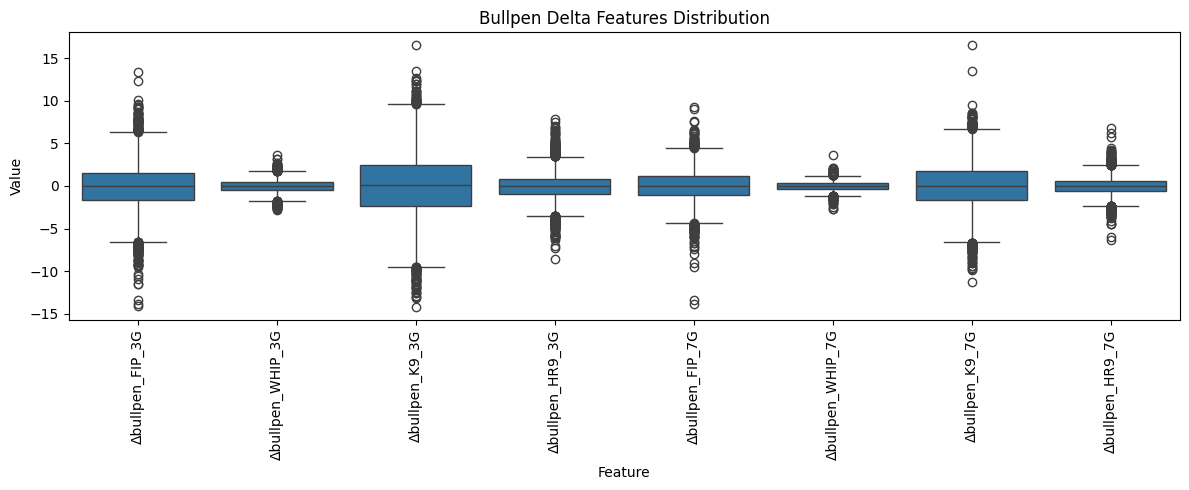

In [11]:
plot_delta_boxplots(game_level_features, like="bullpen", title="Bullpen Delta Features Distribution")

#### Analysis

The distributions of the bullpen delta features show patterns very similar to those observed for the starter delta features. Across all metrics, the distributions are centered close to zero, with both means and medians near zero, which is expected since these variables represent the difference between the home and away teams' bullpen performance.

As with the starter metrics, the 3-game rolling windows (3G) exhibit a wider spread than the 7-game windows (7G), reflecting the greater variability of shorter rolling samples. The overall shapes of the distributions are also fairly symmetric around zero.

One noticeable difference is that the bullpen features tend to exhibit slightly larger interquartile ranges than the starter features, indicating somewhat greater variability in recent bullpen performance between teams. Additionally, the bullpen features show fewer extreme values overall, particularly compared to the large outliers observed in starter FIP.

### 3.2 Delta Features by Game Outcome


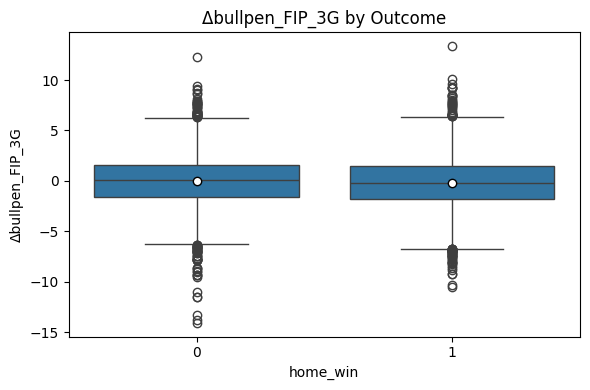

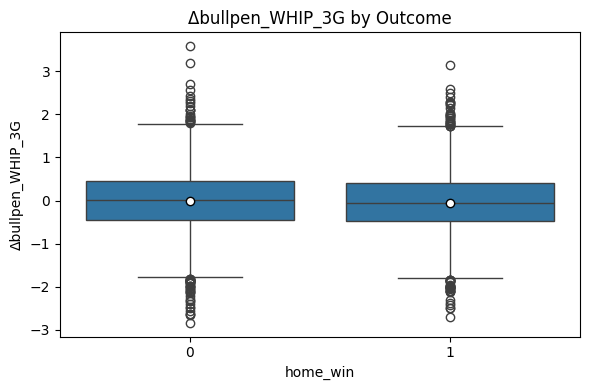

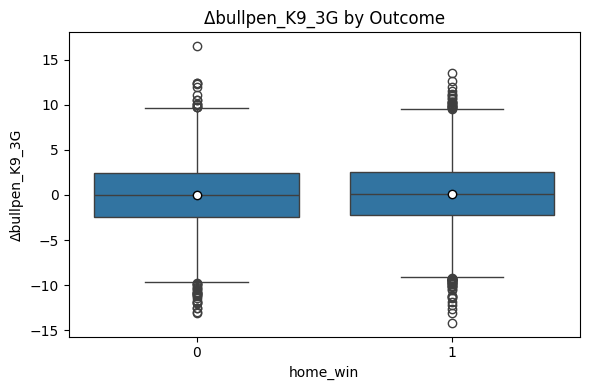

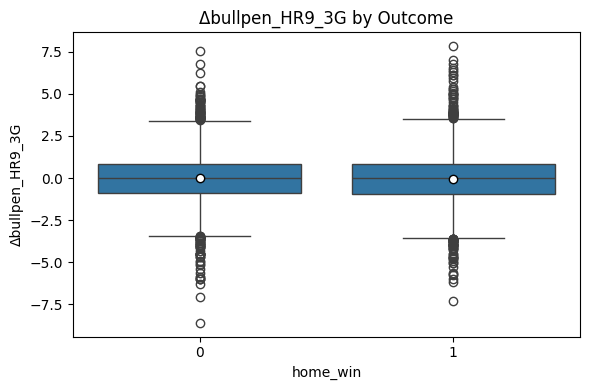

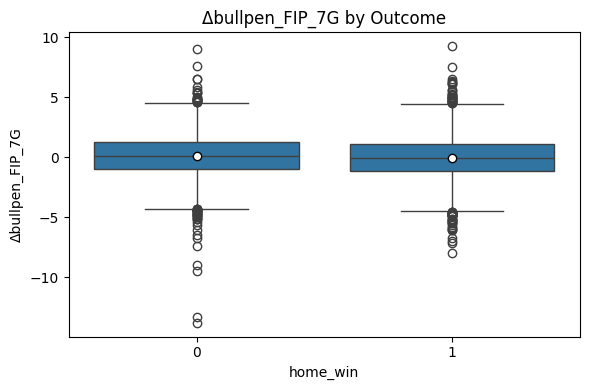

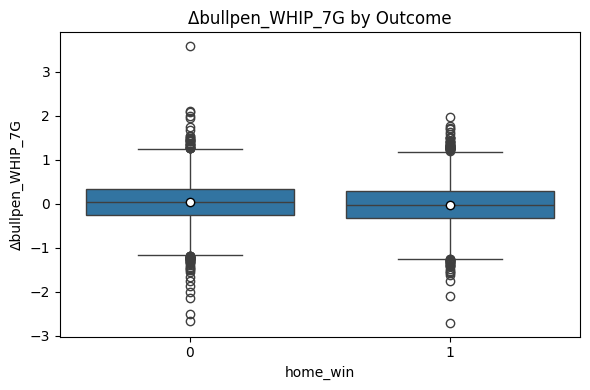

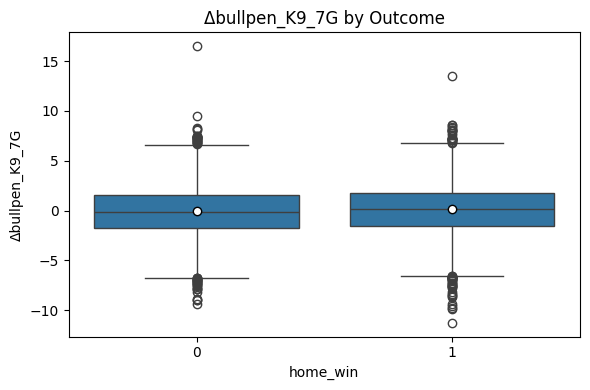

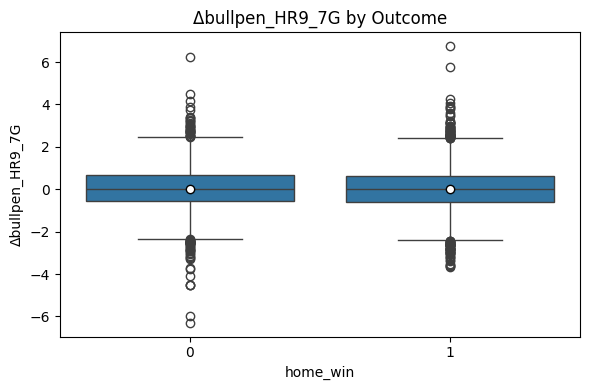

In [11]:
plot_delta_boxplots_by_outcome(
    game_level_features,
    like="Δbullpen_",
    showmeans=True
)

#### Analysis

Across all bullpen delta features (FIP, WHIP, K9, and HR9) for both the 3-game and 7-game rolling windows, the distributions for home wins and losses overlap substantially. Both the **medians and means for the two outcome groups lie close to zero**, indicating that the recent bullpen performance of the two teams is often fairly similar entering a game. The mean markers also appear close to the medians in most plots, suggesting that the distributions are reasonably symmetric despite the presence of several outliers.

However, slight directional tendencies can still be observed. When the home team wins, values of metrics where lower is better (such as $\Delta FIP$ and $\Delta WHIP$) tend to be slightly more negative, while metrics where higher is better (such as $\Delta K9$) tend to be slightly more positive. In these cases, both the **means and medians shift modestly in the expected direction**, suggesting that stronger recent bullpen performance relative to the opponent may contribute some predictive signal.

Overall, these patterns closely mirror those observed in the starting pitching features: pitching advantages appear to matter, but the substantial overlap between the win and loss distributions indicates that bullpen differences alone are unlikely to determine game outcomes without considering other factors such as starting pitching and offensive performance.

###  3.3 Bullpen Pitcher Density Plots by Outcome

The density plots for the bullpen delta features show the distribution of the recent bullpen advantage between the home and away teams, conditional on game outcomes. As with the starting pitcher features, these variables represent the difference between the home and away teams' recent bullpen performance, so values near zero indicate relatively balanced bullpens entering the game, while positive or negative values indicate an advantage for one team.


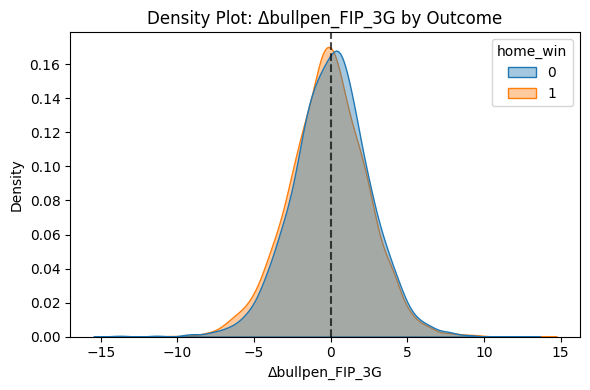

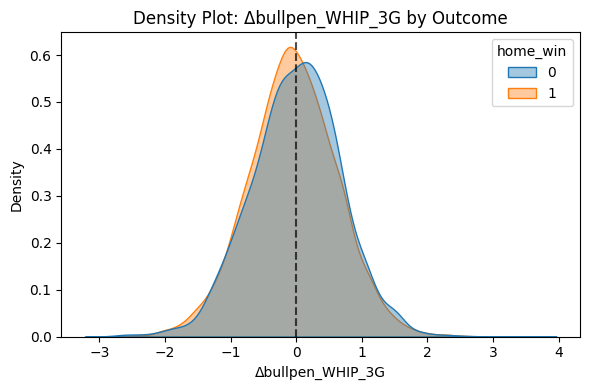

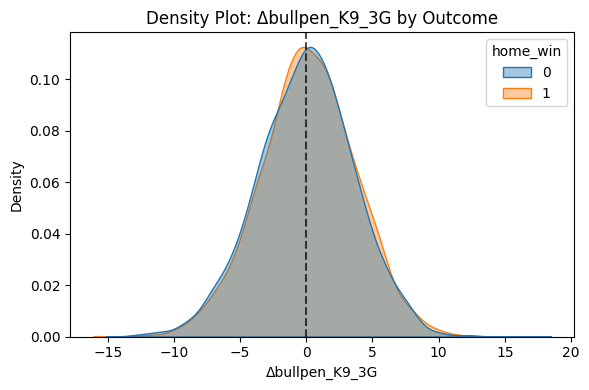

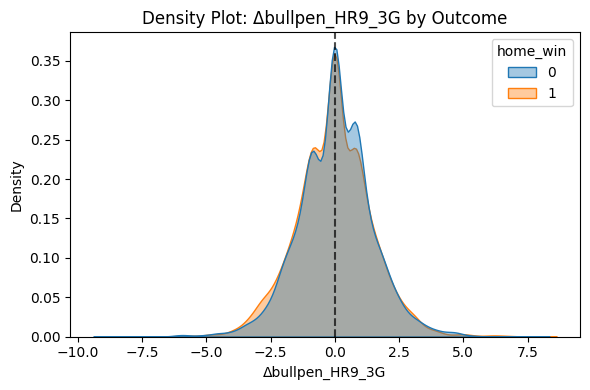

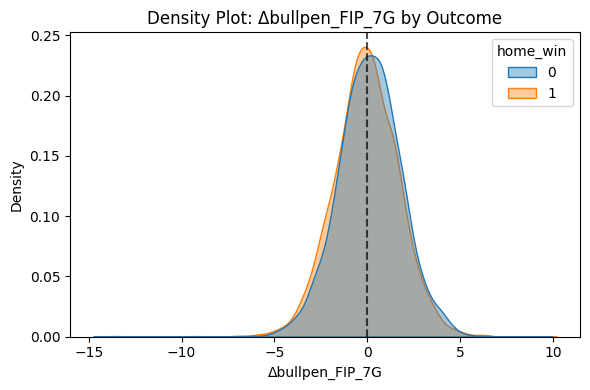

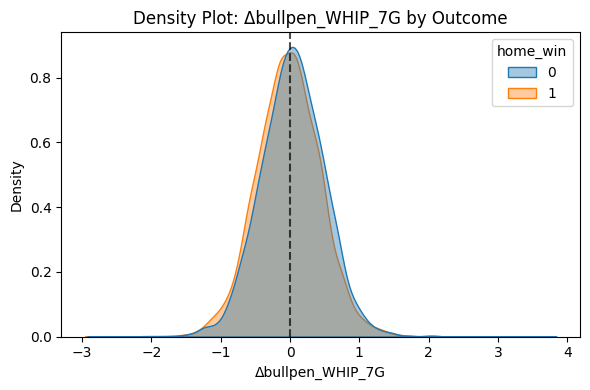

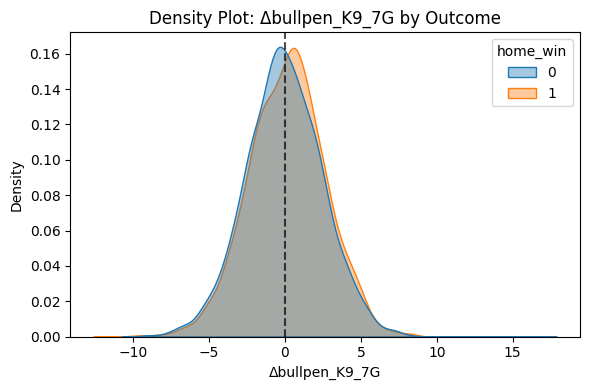

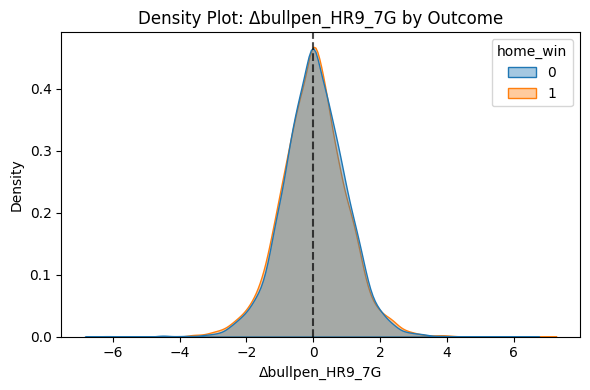

In [18]:
plot_delta_density_by_outcome(
    game_level_features,
    like="Δbullpen_"
)

#### Analysis

The density plots for the bullpen delta features show the distribution of the recent bullpen advantage between the home and away teams, conditional on game outcomes. As with the starting pitcher features, these variables represent the difference between the home and away teams' recent bullpen performance, so values near zero indicate relatively balanced bullpens entering the game, while positive or negative values indicate an advantage for one team.

Across all bullpen metrics (FIP, WHIP, K9, and HR9) and both rolling windows (3-game and 7-game), the distributions for home wins and losses are **strongly concentrated around zero and overlap heavily**. This suggests that, in many games, the recent performance of the two bullpens entering the matchup is fairly similar. The dashed vertical line at zero again highlights that the peaks of both outcome distributions lie very close to this neutral point.

Although the overlap is substantial, **small directional differences are visible**. For metrics where lower values correspond to stronger performance (such as $\Delta$FIP, $\Delta$WHIP, and $\Delta$HR9), the home win distributions tend to shift slightly toward **more negative values**, indicating that games are somewhat more likely to be won when the home bullpen has recently allowed fewer runs, baserunners, or home runs relative to the opponent. Conversely, for $\Delta$K9, where higher values indicate stronger pitching performance, the distribution associated with home wins shifts slightly toward **more positive values**, suggesting that higher recent strikeout rates for the home bullpen may contribute modestly to improved outcomes.

These findings **confirm the patterns observed in the earlier box plots**. The box plots indicated that the medians and means of the win and loss groups were very close together and that their interquartile ranges overlapped significantly. The density plots reinforce this conclusion while also making the **subtle directional shifts between outcome groups easier to see**, particularly in the tails of the distributions.

Comparing rolling windows, the **3-game bullpen features exhibit slightly wider distributions**, reflecting the greater volatility of very recent bullpen performance. The **7-game windows appear somewhat smoother and more concentrated**, as averaging over a larger number of games reduces short-term fluctuations.

Overall, the bullpen density plots suggest that **relative bullpen performance contains some predictive information but remains a relatively weak standalone signal**. The large degree of overlap between win and loss distributions indicates that bullpen differences alone rarely determine outcomes, reinforcing the idea that game results are influenced by multiple interacting components such as starting pitching matchups, offensive performance, and situational factors.

## 4. Pitching Correlation Analysis

In [27]:
def plot_delta_corr_heatmap(
    df: pd.DataFrame,
    group: str = "pitching",  # "pitching", "batting", "fielding", "winning", "all"
    prefix: str = "Δ",
    group_map: dict[str, tuple[str, ...]] | None = None,
    figsize: tuple[int, int] = (12, 10),
    title: str | None = None,
    fmt: str = ".2f",
    annot_fontsize: int = 8,
) -> None:
    """
    Plot a lower-triangle correlation heatmap for delta features.

    Default group_map:
      pitching -> ("Δstarter_", "Δbullpen_")
      batting  -> ("Δroll_",)
      fielding -> ("ΔBIP_",)
      winning  -> ("Δwin_pct_",)
      all      -> all columns starting with "Δ"

    Returns None (plots only).
    """

    default_group_map = {
        "pitching": (f"{prefix}starter_", f"{prefix}bullpen_"),
        "batting":  (f"{prefix}roll_",),
        "fielding": (f"{prefix}BIP_",),
        "winning":  (f"{prefix}win_pct_",),
        "all":      (prefix,),
    }
    group_map = default_group_map if group_map is None else group_map

    if group not in group_map:
        raise ValueError(f"group must be one of {list(group_map.keys())}. Got: {group}")

    tokens = group_map[group]

    # Select columns
    if group == "all":
        cols = [c for c in df.columns if isinstance(c, str) and c.startswith(prefix)]
    else:
        cols = [c for c in df.columns if isinstance(c, str) and any(c.startswith(t) for t in tokens)]

    if len(cols) < 2:
        raise ValueError(f"Not enough columns found for group='{group}'. Found {len(cols)}.")

    # Sort: 3G before 7G before 10G (if present)
    def _win_rank(c: str) -> int:
        cu = c.upper()
        if cu.endswith("_3G"):
            return 0
        if cu.endswith("_7G"):
            return 1
        if cu.endswith("_10G"):
            return 2
        return 3

    cols = sorted(cols, key=lambda c: (_win_rank(c), c))

    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle incl diagonal

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        corr,
        mask=mask,
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        annot=True,
        fmt=fmt,
        annot_kws={"size": annot_fontsize},
    )

    if title is None:
        title = f"Correlation Heatmap: {group.capitalize()} Delta Features"
    ax.set_title(title)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

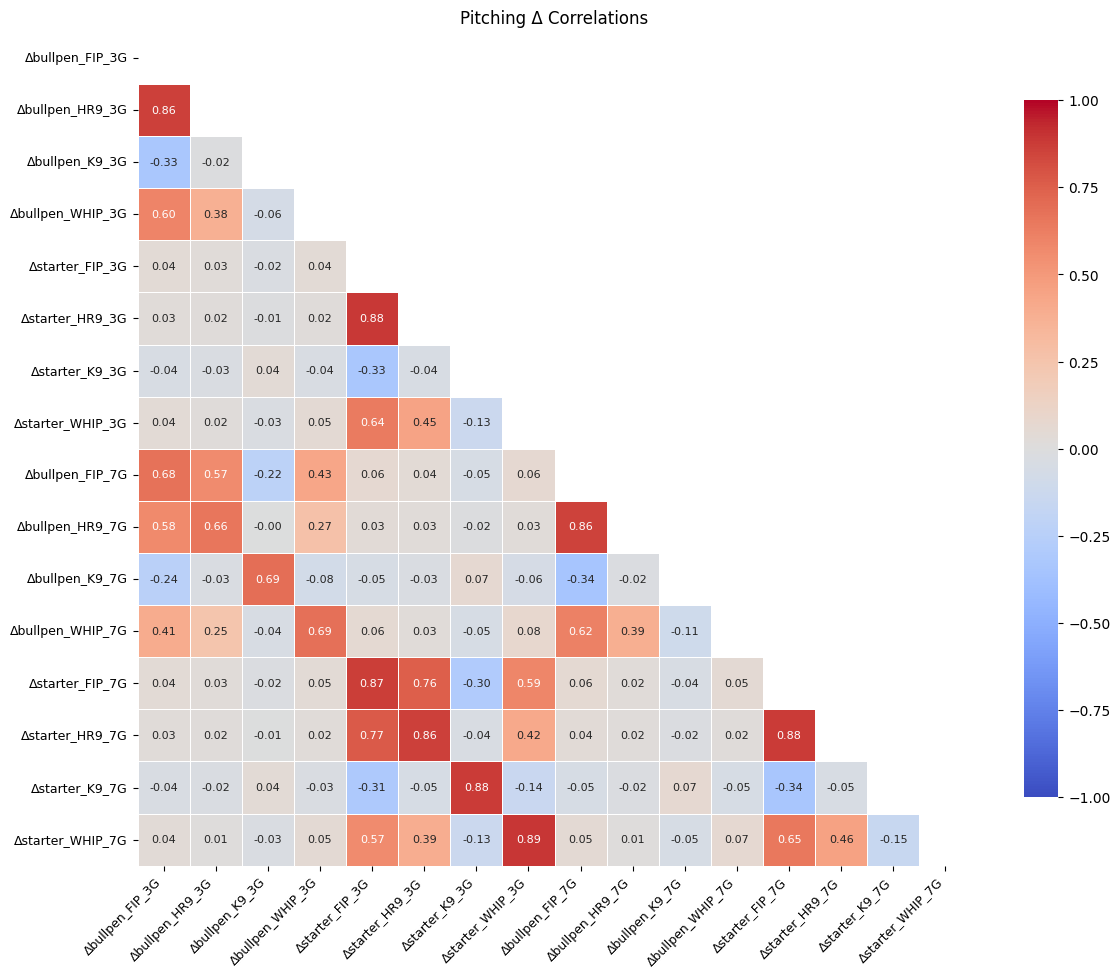

In [28]:
plot_delta_corr_heatmap(game_level_features, group="pitching", title="Pitching Δ Correlations")

#### Pitcher Heatmap Analysis 
| Feature 1          | Feature 2          | Correlation |
|--------------------|--------------------|-------------|
| `Δstarter_WHIP_3G` | `Δstarter_WHIP_7G` | **0.89**    |
| `Δstarter_FIP_3G`  | `Δstarter_HR9_3G`  | **0.88**    |
| `Δstarter_K9_3G`   | `Δstarter_K9_7G`   | **0.88**    |
| `Δstarter_FIP_7G`  | `Δstarter_HR9_7G`  | **0.88**    |
| `Δbullpen_FIP_3G`  | `Δbullpen_HR9_3G`  | **0.86**    |
| `Δbullpen_FIP_7G`  | `Δbullpen_HR9_7G`  | **0.86**    |
| `Δstarter_HR9_3G`  | `Δstarter_HR9_7G`  | **0.86**    |

Two major patterns emerge from the correlation analysis. The first is that **FIP and HR9 are highly correlated**. For example, several pairs such as `Δstarter_FIP_3G` and `Δstarter_HR9_3G` have correlations well above 0.8. This is expected because HR9 is a direct component of FIP, meaning that differences in HR9 between teams strongly influence differences in FIP.

Second, **the 3G and 7G versions of the same metric are strongly correlated**. This pattern appears across both starter and bullpen metrics. This is expected because both rolling windows measure the same underlying skill, with the 7-game window simply providing a smoother estimate of recent performance. To address this during modeling, the **3G and 7G pitching features will be modeled separately**, preventing multicollinearity between different window lengths of the same statistic.

**Additional Notes**

It is also important to note that, while not exceeding the 0.8 threshold, several pairs still exhibit relatively strong correlations. For example, `Δstarter_FIP_7G` and `Δstarter_HR9_3G` have a correlation of 0.76. This further reflects the underlying relationship between HR9 and FIP, as home runs are a direct component of the FIP calculation. As a result, differences in HR9 between teams can still influence FIP even when measured across slightly different rolling windows.

## 5. Batting Analysis 

### 5.1 Batting Distributions

In [29]:
game_level_features.filter(like="Δroll").describe()

,Δroll_3G_OBP,Δroll_3G_ISO,Δroll_7G_OBP,Δroll_7G_ISO
count,9719.000000,9719.000000,9719.000000,9719.000000
mean,0.002625,0.002724,-0.000730,-0.000734
std,0.071909,0.090902,0.050625,0.063383
min,-0.250262,-0.380037,-0.243472,-0.380037
25%,-0.046633,-0.056196,-0.034227,-0.041283
50%,0.002732,0.000690,-0.000728,-0.000203
75%,0.051464,0.062326,0.032433,0.041508
max,0.287214,0.404856,0.287214,0.404856


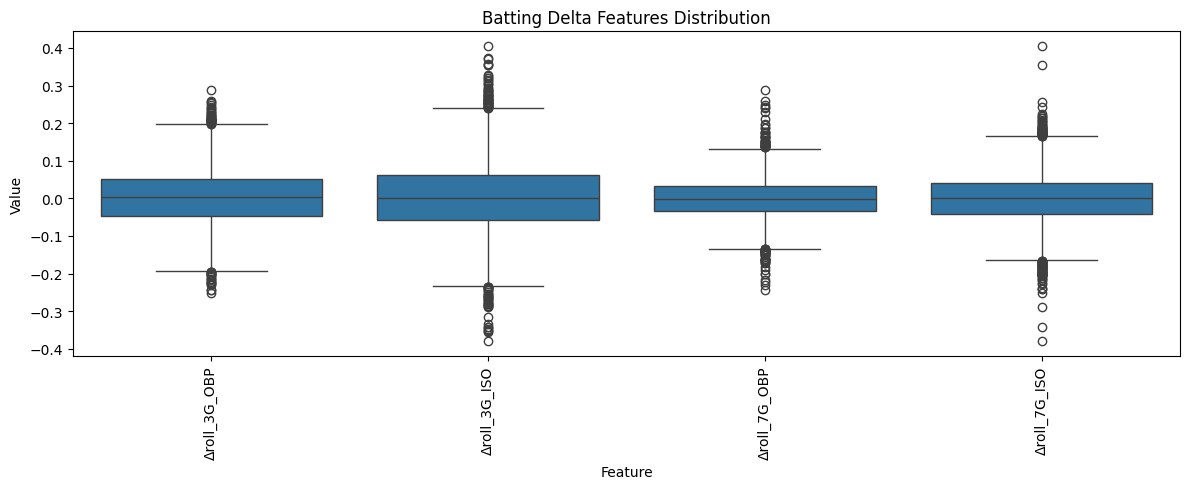

In [30]:
plot_delta_boxplots(game_level_features, like="roll", title="Batting Delta Features Distribution")

#### Analysis

The batting delta features (OBP and ISO) are centered very close to zero across both rolling windows, with means and medians near zero. This is expected since these variables represent the difference between the home and away teams’ recent batting performance entering a game.

Overall, the distributions appear roughly symmetric around zero. The first and third quartiles are fairly balanced around zero for both OBP and ISO, suggesting that positive and negative batting advantages occur at similar rates across games.

As expected, the 3-game rolling windows (3G) show a wider spread than the 7-game rolling windows (7G), reflecting the greater volatility of shorter samples. This is visible in the larger standard deviations for 3G compared to 7G for both OBP and ISO.

Finally, while outliers exist for both windows, they are relatively bounded compared to the pitching metrics, which is consistent with OBP and ISO being rate-based statistics that typically vary within a narrower range.

### 5.2 Batting Delta Features by Game Outcome


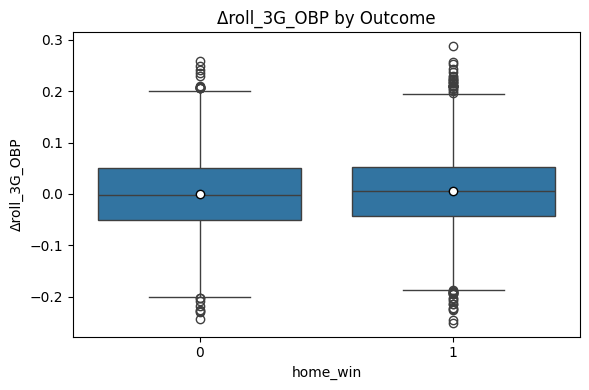

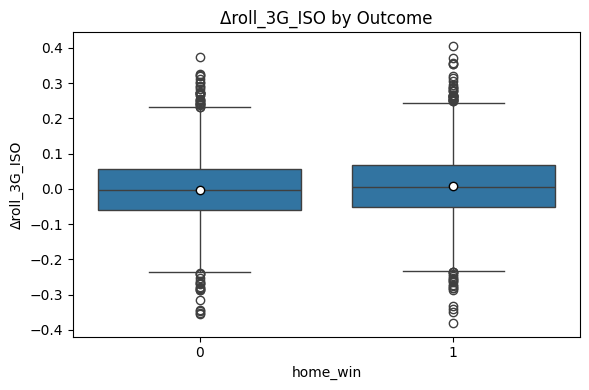

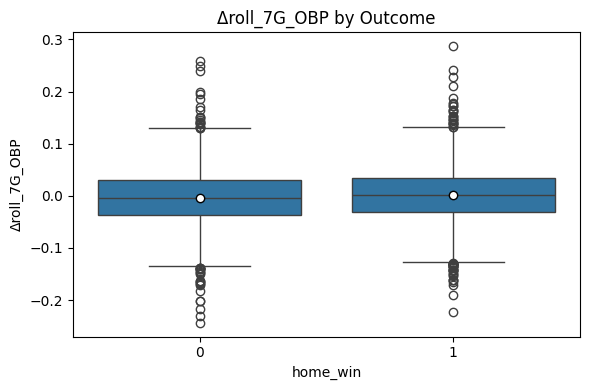

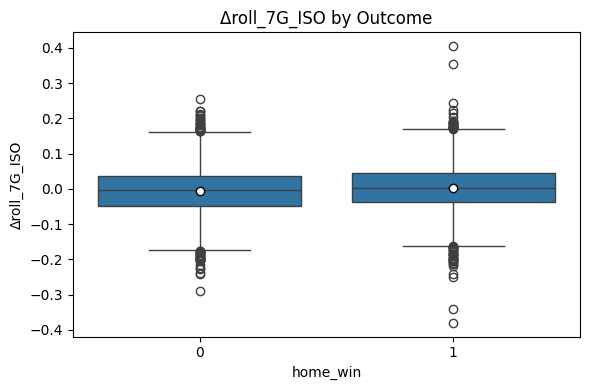

In [12]:
plot_delta_boxplots_by_outcome(
    game_level_features,
    like="Δroll_",
    showmeans=True
)

#### Analysis 

Across all four batting delta features (OBP and ISO for both the 3-game and 7-game rolling windows), the distributions for wins and losses show substantial overlap, indicating that recent offensive differences alone do not strongly separate game outcomes. Both the **medians and mean markers remain close to zero**, suggesting that in many games the recent offensive performance of the two teams entering the matchup is relatively similar. The means also appear close to the medians across the plots, indicating that the distributions are generally symmetric despite the presence of several extreme observations.

However, a consistent directional pattern can still be observed across the plots. Because the batting delta features are defined as the difference between the home and away teams' recent performance, positive values indicate that the home team has been performing better offensively entering the game, while negative values indicate an advantage for the away team. In the plots, games where the home team wins tend to exhibit slightly more positive values, while games where the home team loses tend to show values closer to zero or slightly negative. This tendency is reflected in both the **mean and median values shifting modestly in the positive direction for home wins**.

This pattern appears consistently across both OBP and ISO metrics and across both rolling windows. The 7-game windows show somewhat tighter distributions than the 3-game windows, reflecting the smoothing effect of the longer sample and reducing the influence of short-term fluctuations in offensive performance. Overall, the results suggest that relative offensive performance provides a **modest but consistent signal** in predicting game outcomes, although the substantial overlap between the win and loss distributions indicates that batting differences alone are unlikely to fully determine results without accounting for other aspects of the game such as pitching and situational factors.

### 5.3 Batting  Density Plots by Outcome

The density plots for the batting delta features illustrate the distribution of the recent offensive advantage between the home and away teams entering each game. Because these variables represent the difference between the home and away teams' recent performance, values near zero indicate similar offensive performance, while positive values indicate that the home team has been performing better offensively in the recent rolling window.


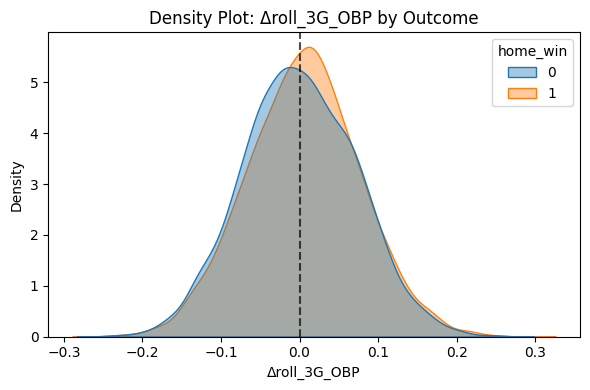

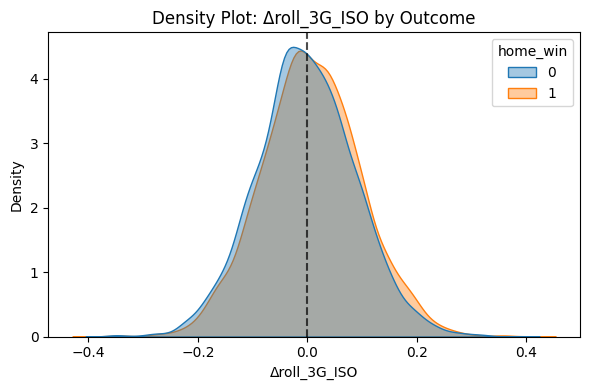

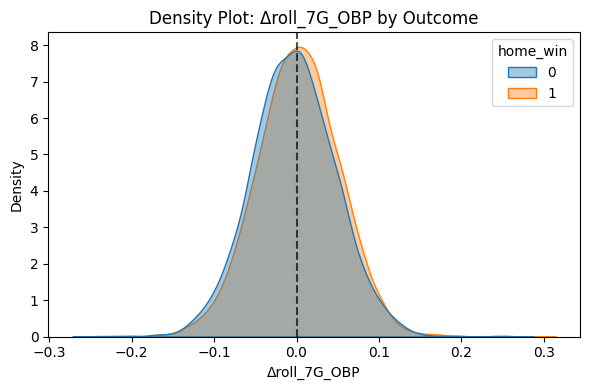

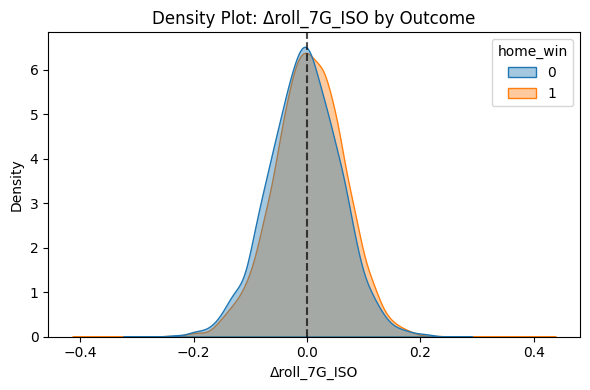

In [19]:
plot_delta_density_by_outcome(
    game_level_features,
    like="Δroll_"
)

#### Analysis

Across all batting metrics (OBP and ISO) and both rolling windows (3-game and 7-game), the distributions for home wins and losses remain **centered very close to zero and overlap considerably**. This indicates that, in many games, the recent offensive performance of the two teams entering the matchup is relatively similar. The dashed vertical line at zero highlights this point, as the peak density of both outcome groups lies very close to the neutral point where neither team holds a recent offensive advantage.

Despite the strong overlap, **small directional shifts are visible across all four features**. In each case, the distribution corresponding to home wins is shifted slightly toward **more positive values**, indicating that games the home team wins are somewhat more likely to occur when the home team has recently performed better offensively relative to the away team. Conversely, the distribution for home losses tends to be centered slightly closer to zero or marginally negative values. This pattern is consistent with the interpretation of the delta features, where positive values indicate a recent offensive advantage for the home team.

These results **reinforce the patterns observed in the earlier box plots**. The box plots suggested that both the means and medians for wins and losses were close to zero but exhibited small directional differences. The density plots confirm this conclusion while making the **slight rightward shift in the win distributions easier to visualize**, particularly in the central region of the distributions.

Comparing rolling windows, the **3-game distributions appear slightly wider**, reflecting the greater volatility of very short-term offensive performance. The **7-game windows produce smoother and more concentrated distributions**, as they average performance across a larger sample of recent games and therefore reduce the impact of short-term fluctuations.

Overall, the batting density plots suggest that **relative offensive performance provides a modest but consistent predictive signal**. While the substantial overlap between win and loss distributions indicates that batting differences alone cannot fully determine outcomes, the consistent rightward shift for home wins suggests that games are somewhat more likely to be won when the home team enters the matchup with stronger recent offensive performance.

### 5.4 Batting Correlation Analysis

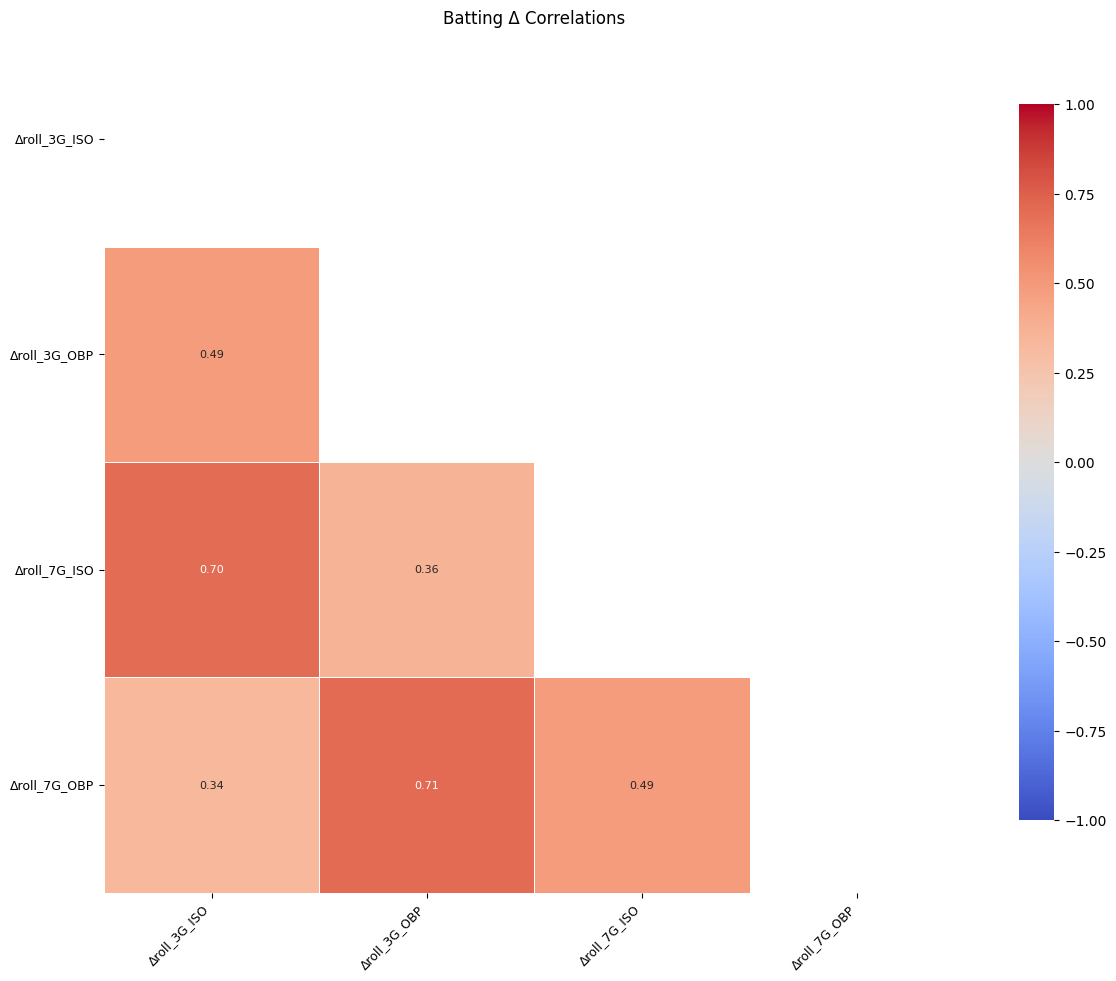

In [32]:
plot_delta_corr_heatmap(game_level_features, group="batting", title="Batting Δ Correlations")

#### Analysis


The batting delta features show moderate correlations but no extremely high multicollinearity. The strongest relationships occur between the **3-game and 7-game versions of the same metric**, with correlations of **0.70 for ISO** and **0.71 for OBP**. This is expected since both rolling windows capture the same underlying team hitting performance, but with different smoothing levels.

Correlations between **OBP and ISO** are lower, generally ranging between **0.34 and 0.49**, indicating that while the metrics are related, they capture somewhat different aspects of offensive production. **OBP reflects a team’s ability to reach base**, whereas **ISO measures power and extra-base hitting**. Overall, the correlations are moderate and remain well below the levels observed in some of the pitching features, suggesting that multicollinearity among the batting variables is less of a concern for modeling.

## 6. Fielding Analysis

### 6.1 Fielding Distributions

In [33]:
game_level_features.filter(like="ΔBIP").describe()

,ΔBIP_out_rate_3G,ΔBIP_out_rate_7G
count,9719.000000,9719.000000
mean,-0.000405,-0.001498
std,0.081264,0.055946
min,-0.315279,-0.291667
25%,-0.055785,-0.039070
50%,-0.001321,-0.001471
75%,0.054440,0.035747
max,0.400000,0.400000


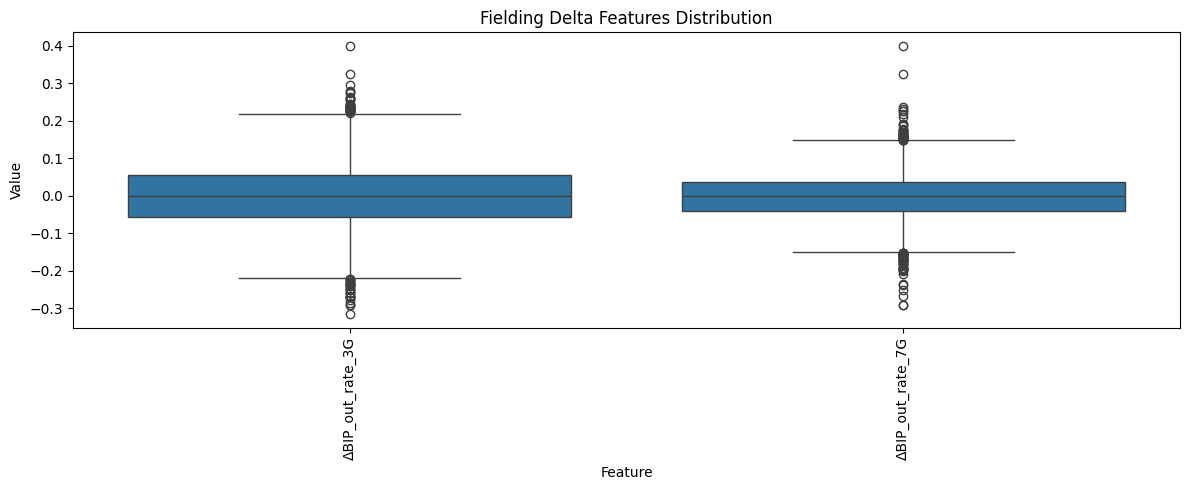

In [34]:
plot_delta_boxplots(game_level_features, like="ΔBIP", title="Fielding Delta Features Distribution")

#### Analysis

The fielding delta features are also centered very close to zero for both `ΔBIP_out_rate_3G` and `ΔBIP_out_rate_7G`. This is expected because the variables represent the **difference in recent defensive performance between the home and away teams**, measured as the proportion of balls in play converted into outs. Across a large sample of games, positive and negative differences between teams tend to balance out, resulting in means and medians very close to zero.

The summary statistics confirm this pattern. The mean values for `ΔBIP_out_rate_3G` and `ΔBIP_out_rate_7G` are −0.0004 and −0.0015 respectively, while the medians are also extremely close to zero. This indicates that, on average, neither the home nor away team consistently enters games with a strong defensive advantage in terms of converting balls in play into outs.

Comparing the rolling windows, the `3G` feature shows greater variability than the `7G` feature. This is reflected in the larger standard deviation for `ΔBIP_out_rate_3G` (0.081) compared with `ΔBIP_out_rate_7G` (0.056), as well as the slightly wider interquartile range visible in the boxplots. Shorter rolling windows tend to be more sensitive to recent fluctuations in defensive performance, while longer windows smooth out this short-term variability.

Overall, the distributions indicate that most games occur between teams with **fairly similar recent fielding performance**, with only modest differences in `ΔBIP_out_rate` appearing across matchups. The clustering of observations near zero suggests that large defensive advantages in recent ball-in-play outcomes occur relatively infrequently.

### 6.2 Fielding Delta Features by Game Outcome


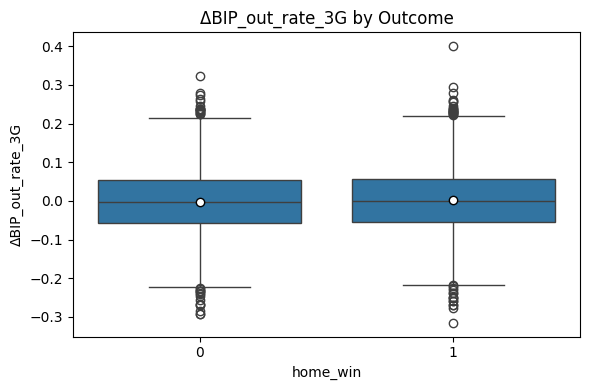

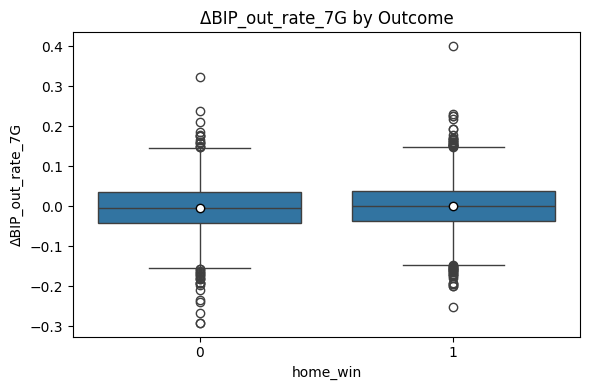

In [13]:
plot_delta_boxplots_by_outcome(
    game_level_features,
    like="ΔBIP",
    showmeans=True
)

#### Analysis

The boxplots for the fielding delta features compare the distribution of `ΔBIP_out_rate` across game outcomes for both the `3G` and `7G` rolling windows. In both plots, the distributions for home wins and losses are centered close to zero, indicating that many games occur between teams with relatively similar recent defensive performance.

A **slight upward shift** is visible for the home-win group in both windows. The mean markers and medians for games the home team wins appear marginally higher than those for games the home team loses, suggesting that when the home team has recently converted a slightly greater share of balls in play into outs relative to its opponent, it may be somewhat more likely to win the game.

However, the **overlap between the two distributions remains substantial**, and the interquartile ranges are very similar across outcomes. This indicates that while defensive performance differences may provide a small amount of predictive information, the signal is relatively modest compared with other potential factors influencing game outcomes.

Comparing the rolling windows, the `3G` distribution shows somewhat greater spread, reflecting the higher sensitivity of shorter windows to recent fluctuations in defensive performance. In contrast, the `7G` window appears slightly more compressed, consistent with the smoothing effect of averaging performance over a longer period.

Overall, these visualizations suggest that **recent defensive performance differences contribute a modest contextual signal**, but like many individual baseball metrics, they are unlikely to strongly distinguish wins from losses on their own.

### 6.3 Fielding Density Plots by Outcome

The density plots for the fielding delta features compare the distribution of `ΔBIP_out_rate` across game outcomes for both the `3G` and `7G` rolling windows. In both plots, the distributions for home wins and losses are centered very close to zero, indicating that most games occur between teams with relatively similar recent defensive performance in terms of converting balls in play into outs.


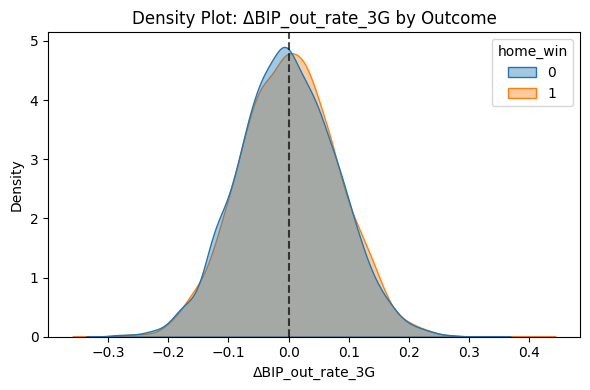

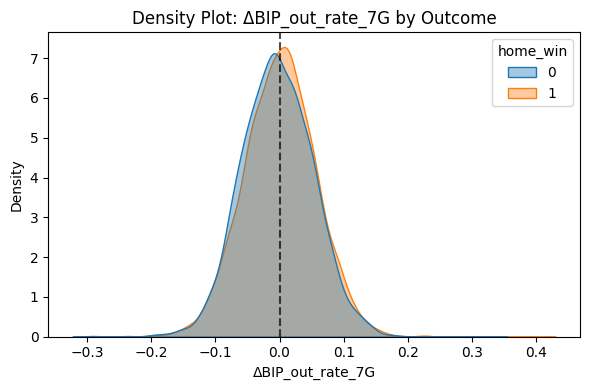

In [23]:
plot_delta_density_by_outcome(
    game_level_features,
    like="ΔBIP"
)

#### Analysis

The curves for wins and losses almost completely overlap in both rolling windows. While the distribution for games the home team wins appears **very slightly shifted to the right**, the difference is minimal. This suggests that when the home team has recently converted a slightly greater share of balls in play into outs relative to its opponent, it may be marginally more likely to win the game. However, the magnitude of this effect appears quite small.

These density plots **confirm the pattern observed in the boxplots**, which also showed that the medians and means for home wins are only slightly higher than those for home losses, with substantial overlap in the interquartile ranges. Together, the visualizations indicate that recent differences in `ΔBIP_out_rate` provide only a modest predictive signal.

Comparing the rolling windows, the `7G` distribution appears slightly smoother and more concentrated than the `3G` distribution. This reflects the typical effect of longer rolling windows, which reduce short-term volatility by averaging performance over a larger number of games.

Overall, the results suggest that **recent defensive performance differences contribute only a small contextual signal** in predicting game outcomes. While slightly better recent fielding performance may be associated with a higher probability of winning, the substantial overlap between the distributions indicates that this feature alone is unlikely to strongly distinguish wins from losses.

### 6.4 Fielding Correlation

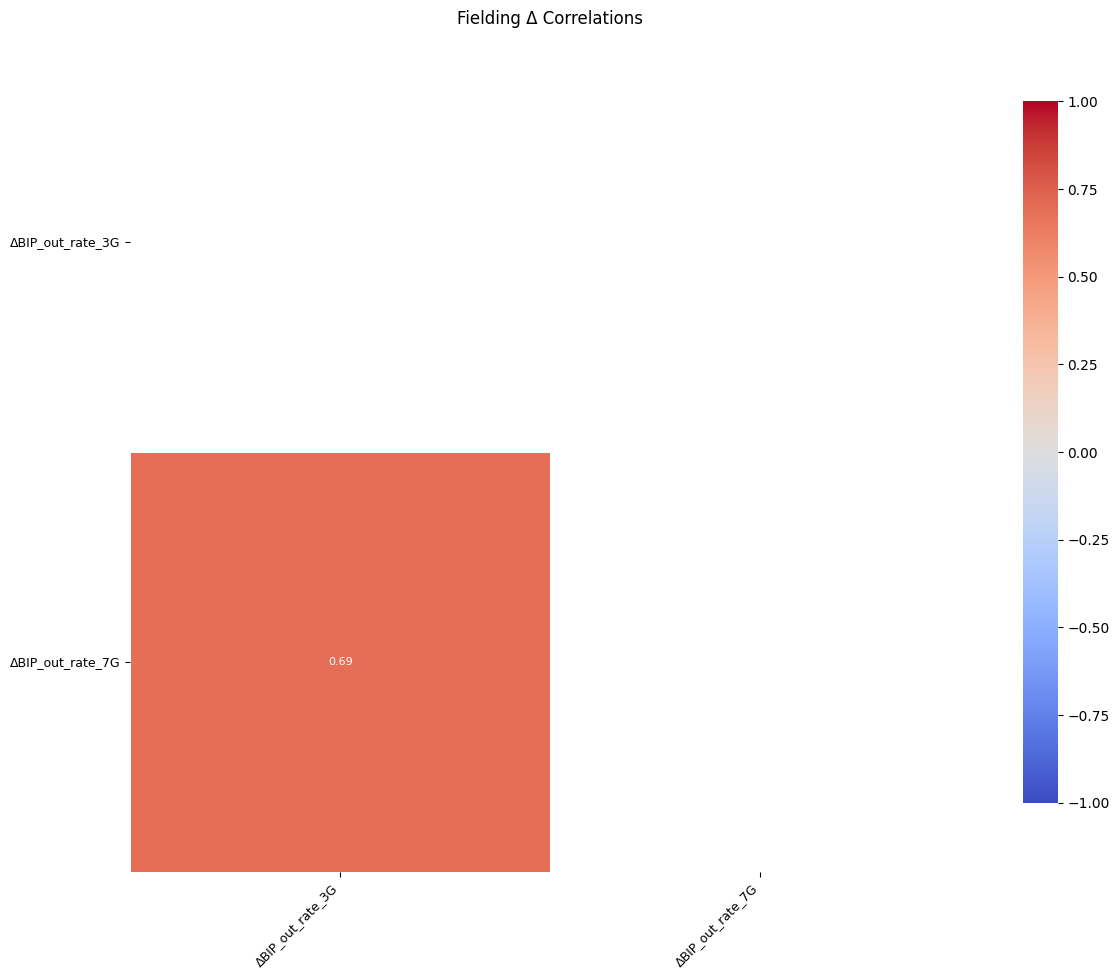

In [36]:
plot_delta_corr_heatmap(game_level_features, group="fielding", title="Fielding Δ Correlations")

#### Analysis

The fielding delta features show a **moderate correlation** between the 3-game and 7-game rolling windows, with a correlation of **0.69** between `ΔBIP_out_rate_3G` and `ΔBIP_out_rate_7G`. This relationship is expected since both variables measure the same underlying defensive metric—the rate at which balls in play are converted into outs—but over different rolling time horizons. Overall, the level of correlation does not appear high enough to raise strong concerns about multicollinearity, especially since the **3G and 7G versions will be modeled separately**.

## 7. Winning Analysis

### 7.1 Winning Percentage Distribution

In [37]:
game_level_features.filter(like="Δwin").describe()

,Δwin_pct_7G,Δwin_pct_10G
count,9719.000000,9719.000000
mean,-0.008681,-0.009277
std,0.326978,0.284258
min,-1.000000,-1.000000
25%,-0.285714,-0.200000
50%,0.000000,0.000000
75%,0.142857,0.200000
max,1.000000,1.000000


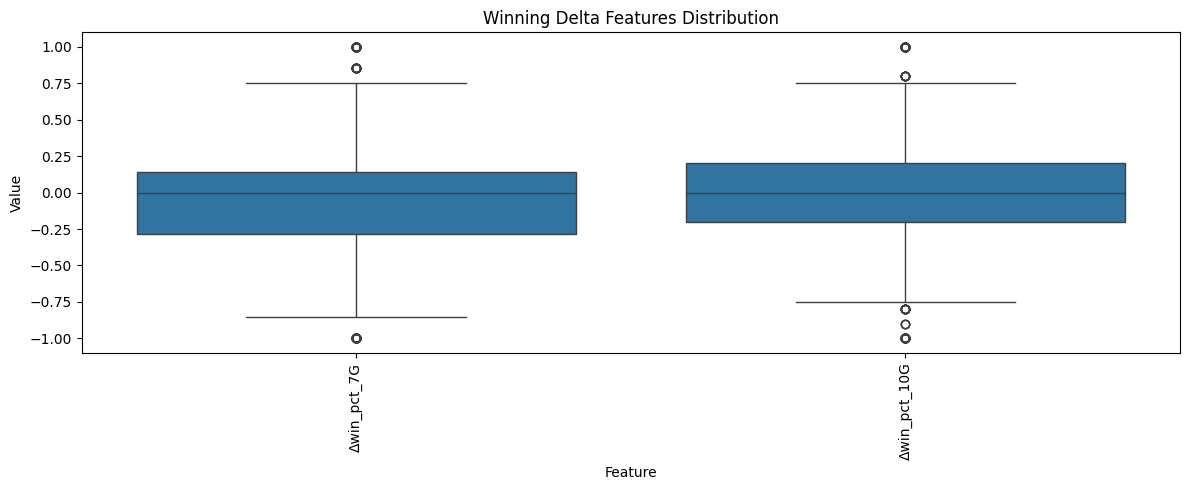

In [20]:
plot_delta_boxplots(game_level_features, like="Δwin", title="Winning Delta Features Distribution")

#### Analysis

The winning percentage delta features are centered very close to zero, with both the mean and median values near zero for the `Δwin_pct_7G` and `Δwin_pct_10G` windows. This is expected because these variables represent the **difference in recent winning performance between the home and away teams**. Since each game involves two teams drawn from the same league, positive and negative differences naturally balance out across the full sample.

The distributions appear relatively symmetric around zero, indicating that games where the home team has recently performed better occur at roughly the same frequency as games where the away team has the stronger recent record. The summary statistics support this pattern: the medians for both `Δwin_pct_7G` and `Δwin_pct_10G` are exactly zero, and the mean values are only slightly negative (−0.0087 and −0.0093 respectively), suggesting only a very small overall imbalance toward away teams having marginally stronger recent records in the dataset.

As with many rolling performance metrics, the `7G` window shows a wider spread than the `10G` window. This is reflected in the larger standard deviation for `Δwin_pct_7G` (0.327) compared with `Δwin_pct_10G` (0.284), as well as the broader interquartile range. Shorter rolling windows react more strongly to recent streaks or slumps, which increases variability, while longer windows smooth out short-term fluctuations in team performance.

The observed values range from −1.00 to +1.00, corresponding to extreme scenarios where one team has recently won all games in the rolling window while the opposing team has lost all of theirs. These cases appear as outliers in the boxplots but are relatively uncommon. Most observations remain clustered near zero, indicating that in the majority of matchups the two teams enter the game with **fairly similar recent winning performance**, and large differences in recent success occur only occasionally.

### 7.2 Winning Percentage Delta Features by Game Outcome


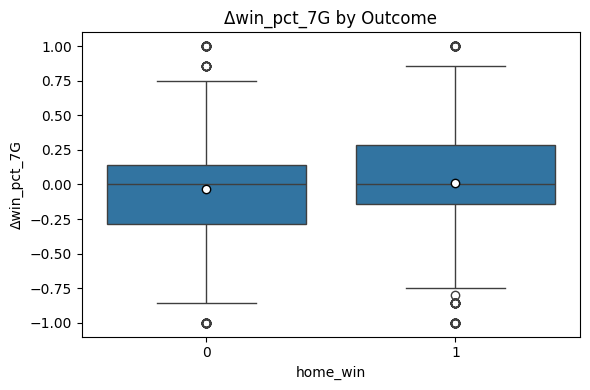

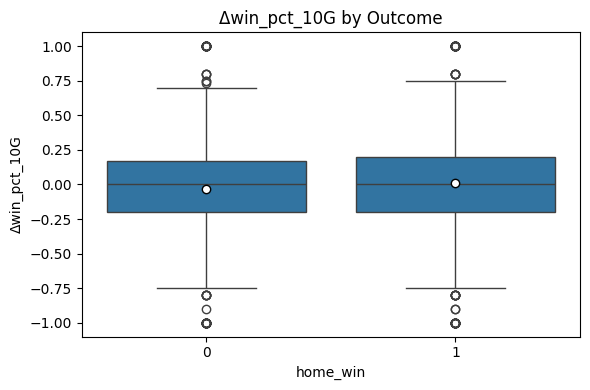

In [15]:
plot_delta_boxplots_by_outcome(
    game_level_features,
    like="Δwin",
    showmeans=True
)

#### Analysis

The boxplots compare the distribution of the winning percentage delta features (`Δwin_pct_7G` and `Δwin_pct_10G`) across game outcomes. In both cases, the distribution corresponding to games the home team wins appears slightly shifted upward relative to games the home team loses. This suggests that when the home team has a stronger recent winning record relative to the away team, it is somewhat more likely to win the game.

For both rolling windows, the **median value for home team wins is modestly higher than for home team losses**, indicating a positive relationship between recent relative performance and game outcomes. The **mean markers also appear slightly higher for home wins**, reinforcing this pattern and suggesting that, on average, games the home team wins tend to occur when the home team has a stronger recent record entering the matchup.

However, there remains substantial overlap between the two distributions. This overlap indicates that while recent winning percentage differences provide some predictive signal, they are not sufficient on their own to clearly distinguish between wins and losses. This is expected, as baseball outcomes depend on many other factors such as pitching matchups, bullpen performance, offensive production, and game-to-game variability.

The spread of the distributions differs slightly between the two rolling windows. The **7-game window shows somewhat greater variability**, reflecting the higher sensitivity of shorter rolling windows to recent streaks or short-term fluctuations in performance. In contrast, the **10-game window appears slightly more compressed**, suggesting that longer rolling windows smooth out some of this volatility.

Overall, the visualizations indicate that **positive differences in recent winning percentage are somewhat more common in games that the home team wins**, supporting the idea that recent team performance contains useful predictive information. However, the substantial overlap between the distributions reinforces that this feature is best interpreted as one component of a broader set of predictors rather than a dominant standalone signal.

### 7.3 Density Plots

The density plots for the recent winning percentage delta features illustrate the distribution of the difference in recent team success between the home and away teams entering each game. Because these variables represent the difference between the home and away teams’ recent winning percentages, values near zero indicate that both teams have performed similarly in recent games, while positive values indicate that the home team has been winning more frequently than the away team over the specified rolling window.


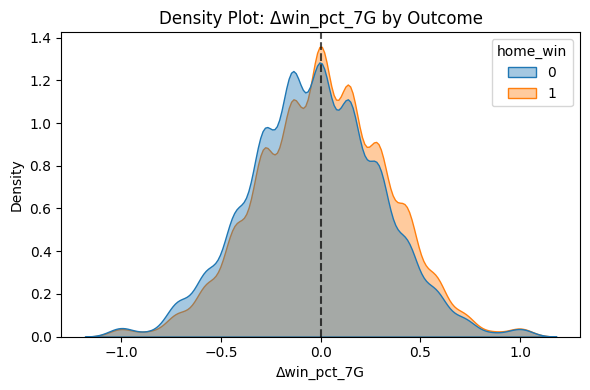

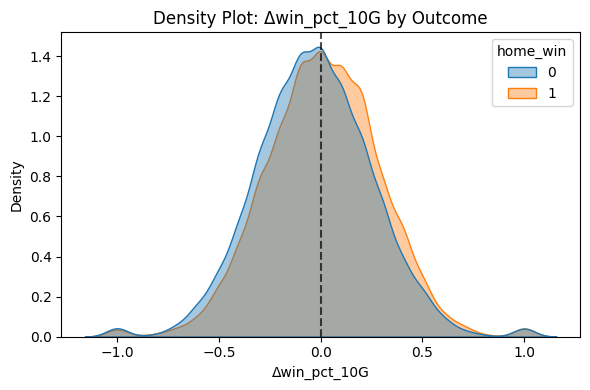

In [22]:
plot_delta_density_by_outcome(
    game_level_features,
    like="Δwin"
)

#### Analysis

Across both rolling windows (7-game and 10-game), the distributions for home wins and losses remain centered near zero, indicating that many games occur between teams with relatively similar recent performance. However, a noticeable **rightward shift in the distributions for home wins** is visible in both plots. Games where the home team wins tend to occur more frequently when the recent winning percentage delta is positive, meaning the home team has been performing better than the away team in the recent sample of games.

Conversely, games where the home team loses tend to show slightly more density in the negative region of the distribution, suggesting that home losses occur somewhat more frequently when the away team has had stronger recent performance. While the two distributions still overlap substantially, the **separation between the curves is more pronounced than in many of the pitching or batting features**, indicating that recent team performance may provide a somewhat stronger predictive signal.

These results **reinforce the patterns observed in the earlier box plots**, which also showed that the distributions of the winning percentage deltas for wins and losses overlap considerably but exhibit a slight rightward shift for home wins. The density plots confirm this finding while making the **directional shift between outcome groups easier to visualize**.

Comparing the two rolling windows, the **10-game distribution appears slightly smoother and more stable** than the 7-game distribution, reflecting the fact that a longer window reduces short-term volatility in team performance. The overall pattern remains consistent across both windows: games are somewhat more likely to be won when the home team enters the matchup with stronger recent winning performance relative to its opponent.

Overall, these density plots suggest that **recent team success provides a meaningful contextual signal for game outcomes**. While the distributions still overlap and therefore cannot perfectly distinguish wins from losses, the consistent rightward shift for home wins indicates that teams with stronger recent records are somewhat more likely to continue winning in the short term.

### 7.4 Winning Correlation

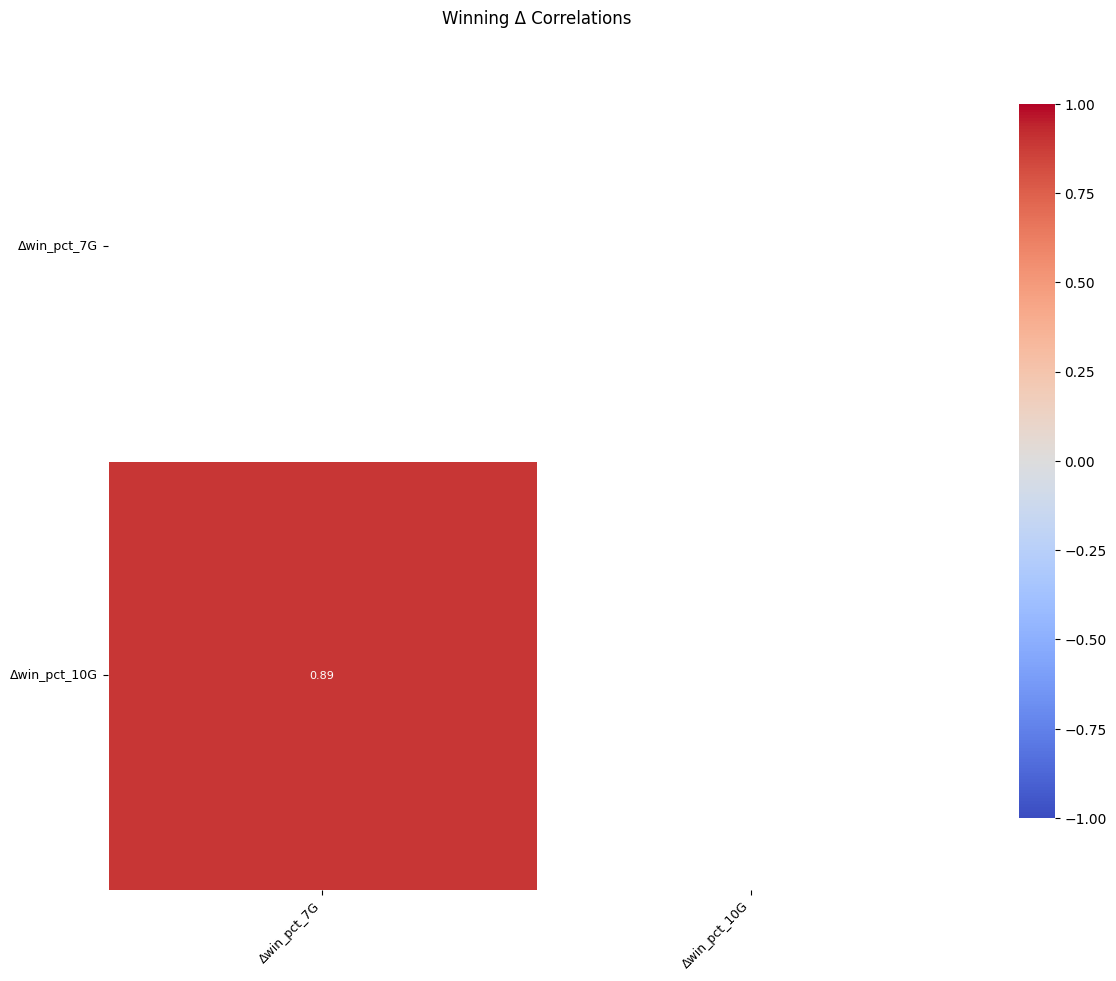

In [41]:
plot_delta_corr_heatmap(game_level_features, group="winning", title="Winning Δ Correlations")

#### Analysis

The correlation coefficient between `Δwin_pct_7G` and `Δwin_pct_10G` is **0.89**, indicating a strong positive relationship. This makes sense since the `10G` window includes most of the same games captured in the `7G` window, meaning the two features naturally move together as team performance improves or declines over time. To avoid redundancy, these two features will be **modeled separately**.

## 8. Overall Correlation

Below, I will examine the correlation for all features.

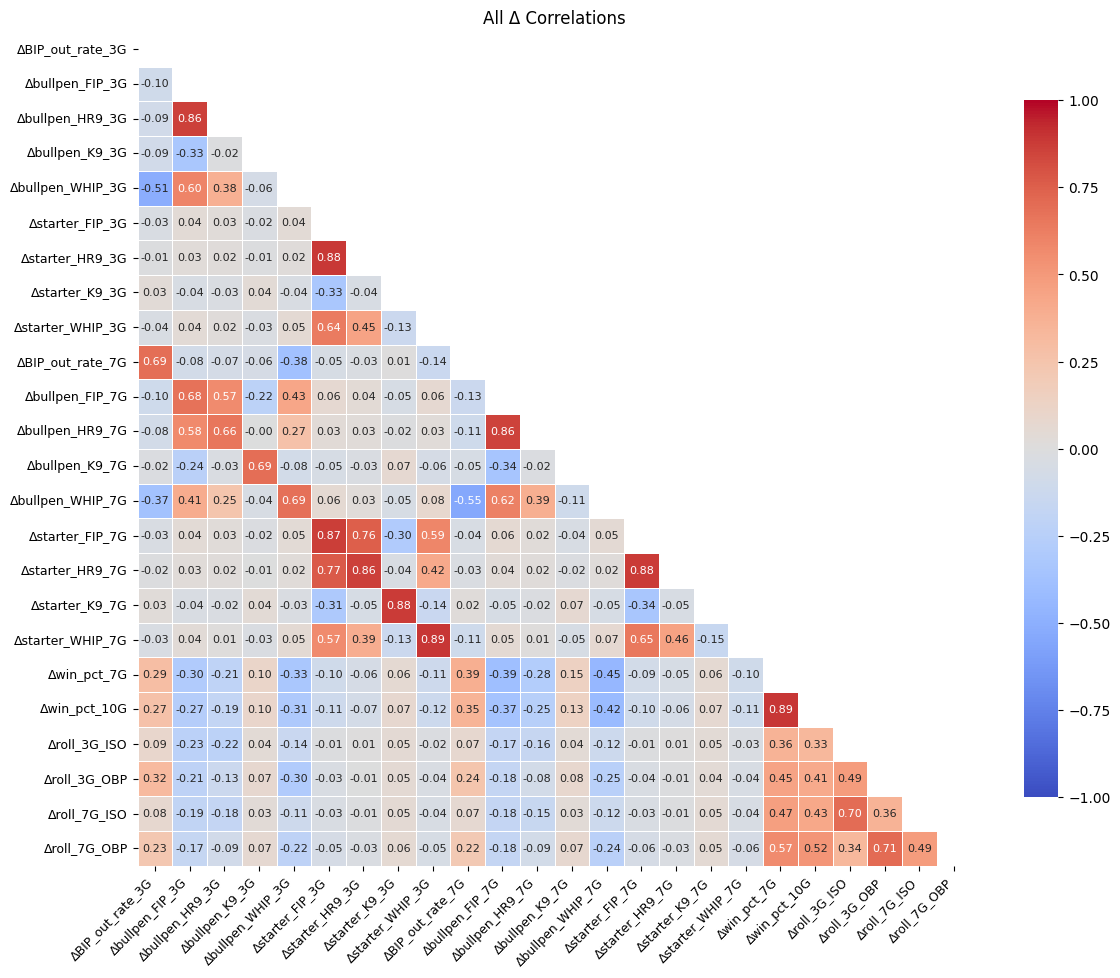

In [40]:
plot_delta_corr_heatmap(game_level_features, group="all", title="All Δ Correlations")

#### Cross-Group Correlations

Across batting, pitching, and fielding features, most correlations are relatively weak, suggesting that these groups capture different aspects of team performance. In general, the **batting metrics show little correlation with pitching or fielding variables**, with most relationships falling below an absolute value of 0.3.

One notable pattern appears between **fielding and bullpen performance**. For example, `ΔBIP_out_rate_3G` and `Δbullpen_WHIP_3G` have a correlation of **−0.51**, while `ΔBIP_out_rate_7G` and `Δbullpen_WHIP_7G` have a correlation of **−0.55**. This negative relationship is intuitive: when a team converts a higher proportion of balls in play into outs, fewer baserunners tend to reach base, which corresponds to lower WHIP values.

Another notable pattern appears between **recent offensive performance and recent winning percentage**. The batting features show moderate positive correlations with the winning delta variables. For example, `Δroll_7G_OBP` correlates **0.57** with `Δwin_pct_7G`, while `Δroll_7G_ISO` correlates **0.47**. Similar but slightly weaker relationships appear for the `3G` batting windows. This suggests that teams with stronger recent offensive production tend to also have stronger recent winning performance.

Overall, aside from the moderate relationships between fielding and bullpen metrics and the connection between batting performance and recent winning percentage, **cross-group correlations remain modest**, indicating that batting, pitching, and fielding variables provide largely distinct information about team performance.

## 9. Feature vs Target Correlation

In [43]:
cols_to_drop = [
    "game_id",
    "game_date",
    "home_team",
    "away_team",
    "starter_pitcher_name_home",
    "starter_pitcher_name_away",
    "run_diff",
    "home_win",
    "ballpark"
]

feature_target_corr = (
    game_level_features
    .drop(columns=cols_to_drop)
    .corrwith(game_level_features["home_win"])
    .sort_values()
)

feature_target_corr

Δbullpen_WHIP_7G   -0.064040
Δstarter_WHIP_3G   -0.050684
Δbullpen_FIP_7G    -0.050142
Δstarter_WHIP_7G   -0.045431
Δbullpen_FIP_3G    -0.040391
Δstarter_FIP_7G    -0.038217
Δbullpen_WHIP_3G   -0.037335
Δstarter_FIP_3G    -0.030552
Δbullpen_HR9_3G    -0.021224
Δbullpen_HR9_7G    -0.015058
Δstarter_HR9_7G    -0.010939
Δstarter_HR9_3G    -0.006428
ΔBIP_out_rate_3G    0.018339
Δbullpen_K9_3G      0.023608
Δroll_3G_OBP        0.035070
Δstarter_K9_3G      0.036902
ΔBIP_out_rate_7G    0.037299
Δbullpen_K9_7G      0.037943
Δstarter_K9_7G      0.049941
Δroll_7G_OBP        0.051964
Δroll_3G_ISO        0.056780
Δwin_pct_7G         0.065496
Δroll_7G_ISO        0.068526
Δwin_pct_10G        0.076186
dtype: float64

#### Analysis

The correlations between the matchup delta features and the target variable (`home_win`) are generally small in magnitude, ranging from approximately **−0.06 to 0.08**. This is expected in sports prediction problems, where game outcomes depend on multiple interacting factors rather than a single dominant variable. As a result, individual features often provide only modest predictive signals on their own.

The pitching metrics tend to show **negative correlations** with the target variable, particularly for statistics where **lower values indicate better performance**, such as WHIP and FIP. Because the features are defined as the difference between the home and away teams’ metrics, negative values indicate that the home team’s pitchers have been performing better recently. The negative correlations therefore suggest that when the home team has a pitching advantage—especially in **bullpen WHIP and FIP**—the probability of a home win increases slightly.

In contrast, the batting metrics show **positive correlations** with the target. Metrics such as `Δroll_7G_OBP` and `Δroll_7G_ISO` exhibit some of the strongest positive relationships with `home_win`, indicating that when the home team has recently outperformed the opponent offensively, the likelihood of winning tends to increase. Among the offensive variables, **ISO (a measure of power hitting)** shows some of the strongest positive correlations.

Fielding performance, measured by `ΔBIP_out_rate`, shows **small positive correlations**, suggesting that defensive advantages may contribute modestly to game outcomes but likely play a smaller role relative to pitching and offensive differences.

Overall, the results align with typical baseball dynamics: **pitching advantages help limit the opponent’s scoring opportunities, while offensive advantages increase the home team’s run-scoring potential**. However, the relatively small magnitude of the correlations indicates that no single metric strongly determines game outcomes, reinforcing the need to consider multiple features together in predictive modeling.

## 10. Feature Variance Check

Below, I conduct variance check to ensure that the engineered features contain sufficient variability across games. Features with extremely low variance can provide little predictive information and may indicate problems in feature construction.


In [44]:
feature_cols = [c for c in game_level_features.columns if c.startswith("Δ")]

variance_df = (
    game_level_features[feature_cols]
    .var()
    .sort_values()
)

variance_df

Δroll_7G_OBP         0.002563
ΔBIP_out_rate_7G     0.003130
Δroll_7G_ISO         0.004017
Δroll_3G_OBP         0.005171
ΔBIP_out_rate_3G     0.006604
Δroll_3G_ISO         0.008263
Δwin_pct_10G         0.080803
Δwin_pct_7G          0.106915
Δbullpen_WHIP_7G     0.215768
Δstarter_WHIP_7G     0.440332
Δbullpen_WHIP_3G     0.463566
Δstarter_WHIP_3G     0.560097
Δbullpen_HR9_7G      0.936064
Δstarter_HR9_7G      1.834379
Δbullpen_HR9_3G      2.105375
Δstarter_HR9_3G      2.514672
Δbullpen_FIP_7G      3.022146
Δstarter_FIP_7G      5.848817
Δbullpen_K9_7G       6.385618
Δbullpen_FIP_3G      6.549272
Δstarter_FIP_3G      7.797487
Δstarter_K9_7G      10.453480
Δbullpen_K9_3G      13.074754
Δstarter_K9_3G      13.760798
dtype: float64

#### Feature Variance Check

The variance results indicate that all delta features exhibit meaningful variation across the dataset. Importantly, none of the engineered variables display near-zero variance, suggesting that each feature contains sufficient variability to potentially contribute information to the predictive model.

The smallest variances occur for the batting metrics (`Δroll_OBP` and `Δroll_ISO`) and the fielding metric (`ΔBIP_out_rate`). This is expected because these statistics are naturally bounded within relatively small ranges. For example, on-base percentage and isolated power typically vary only within a few tenths, which limits the magnitude of possible differences between teams.

In contrast, pitching metrics such as `K9`, `HR9`, and `FIP` show substantially larger variances. This does not necessarily imply that they contain more predictive information, but rather reflects the **larger numeric scale and wider natural range** of these statistics. Differences in strikeout rates or fielding independent pitching between teams can span several units, which leads to higher variance values.

Overall, the variance check confirms that **all engineered features exhibit adequate variability and none appear to be constant or near-constant**, indicating that they are suitable for inclusion in the modeling stage.

## Temporal Analysis

In [38]:
game_level_features["season"] = pd.to_datetime(game_level_features["game_date"]).dt.year
game_level_features["month"] = game_level_features["game_date"].dt.month

In [39]:
team_games = pd.concat([
    game_level_features[["season", "game_date", "home_team", "home_win"]]
        .rename(columns={"home_team": "team", "home_win": "win"}),

    game_level_features[["season", "game_date", "away_team", "home_win"]]
        .rename(columns={"away_team": "team", "home_win": "win"})
        .assign(win=lambda x: 1 - x["win"])
])


In [40]:
team_games = team_games.sort_values(["season","team","game_date"])

team_games["game_number"] = (
    team_games
    .groupby(["season","team"])
    .cumcount() + 1
)

team_games

,season,game_date,team,win,game_number
8,2022,2022-04-08,ATH,0,1
20,2022,2022-04-09,ATH,0,2
35,2022,2022-04-10,ATH,1,3
54,2022,2022-04-11,ATH,1,4
66,2022,2022-04-12,ATH,0,5
...,...,...,...,...,...
9644,2025,2025-09-23,WSH,0,158
9655,2025,2025-09-24,WSH,1,159
9674,2025,2025-09-26,WSH,0,160
9699,2025,2025-09-27,WSH,1,161


In [41]:
win_by_game = (
    team_games
    .groupby("game_number")["win"]
    .mean()
)

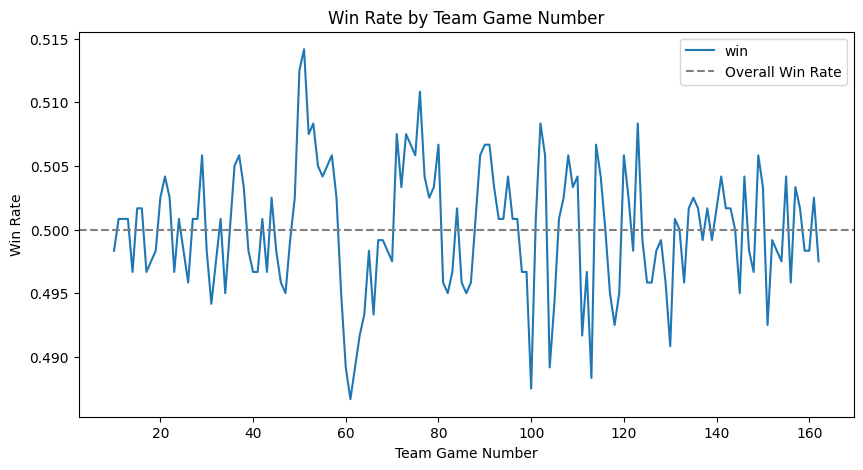

In [42]:
plt.figure(figsize=(10,5))

win_by_game.rolling(10).mean().plot()

plt.axhline(
    team_games["win"].mean(),
    linestyle="--",
    color="gray",
    label="Overall Win Rate"
)

plt.xlabel("Team Game Number")
plt.ylabel("Win Rate")
plt.title("Win Rate by Team Game Number")
plt.legend()

plt.show()

#### Temporal Variation in Win Rate

To examine whether game outcomes vary over the course of the season, a `game_number` variable was constructed for each team representing the chronological order of games played within a season. The win rate was then averaged across all teams for each game number and visualized with a smoothed trend.

The resulting pattern shows that the overall win rate remains relatively stable throughout the season, fluctuating only slightly around the overall average of approximately 0.50. While small short-term deviations appear at certain points in the season, these fluctuations are minor and likely reflect normal sampling variability rather than systematic changes in team performance over time.

Importantly, there is no clear upward or downward trend as the season progresses. This suggests that the probability of winning a game does not meaningfully depend on how far into the season a team is. As a result, explicit temporal variables are unlikely to provide substantial additional predictive power beyond the rolling performance features already included in the model.

### Monthly Analysis



In [43]:
win_by_month = (
    game_level_features
    .groupby("month")["home_win"]
    .mean()
)

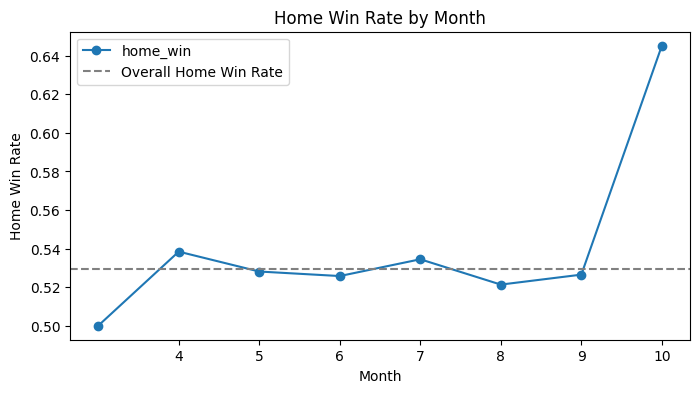

In [44]:
plt.figure(figsize=(8,4))

win_by_month.plot(marker="o")

plt.axhline(
    game_level_features["home_win"].mean(),
    linestyle="--",
    color="gray",
    label="Overall Home Win Rate"
)

plt.xlabel("Month")
plt.ylabel("Home Win Rate")
plt.title("Home Win Rate by Month")
plt.xticks([4,5,6,7,8,9,10])
plt.legend()

plt.show()

### Temporal Variation by Month

To examine whether game outcomes vary across the baseball season, the home win rate was calculated for each month. This provides a simple way to evaluate whether seasonal factors such as early-season randomness or late-season roster changes influence the probability of a home win.

Across the main months of the regular season (April through September), the home win rate remains relatively stable and fluctuates only slightly around the overall average. These variations are small and do not suggest a clear seasonal trend in win probability.

The values observed in March and October deviate more noticeably from the overall average; however, these months contain substantially fewer games and therefore produce noisier estimates of the win rate. As a result, they should not be interpreted as meaningful seasonal effects.

Overall, the results indicate that **home win probability remains largely consistent throughout the regular season**, suggesting that temporal position within the season does not meaningfully influence game outcomes beyond the team performance features already captured in the model.